# Предиктивное обслуживание электротранспорта — Продвинутое моделирование SOH/RUL (NASA Li-ion Battery Aging Dataset)

## Описание датасета

**Датасет:** NASA Li-ion Battery Aging Dataset (полный набор BatteryAgingARC, батареи B0005–B0056).

**Источник данных для этого ноутбука:** очищенный датасет `final_df_clean.csv`, сформированный в ноутбуке **`battery_eda.ipynb`** (разведочный анализ и очистка).

---

### **Назначение ноутбука**

Это **третий ноутбук** в цепочке дипломного проекта. Он решает задачу **продвинутого моделирования**: прогноз двух ключевых показателей состояния батареи — **SOH** (State of Health) и **RUL** (Remaining Useful Life) — с реализацией системы предупреждений.

| Параметр | Значение |
|:--------|:--------|
| **Целевые переменные** | `soh` (%), `rul` (циклы до EOL - End of Life) |
| **Признаки** | 11 признаков: cycle, cycle_normalized, cycle_squared, initial_capacity, soh, soh_rmean_5, soh_rmean_10, soh_slope_10, soh_drop, degradation_rate, capacity |
| **Модели** | Random Forest, XGBoost, LSTM (отдельные для SOH и RUL), ансамбль |
| **Система предупреждений** | 4 уровня: ЗЕЛЕНЫЙ / ЖЕЛТЫЙ / ОРАНЖЕВЫЙ / КРАСНЫЙ |
| **Датасет** | `final_df_clean` из `battery_eda.ipynb` (2765 строк, 33 батареи) |

**Ключевые улучшения (v7.5):**
- **Гибридный динамический RUL (V4):** комбинирует пропорциональную оценку и локальную линейную экстраполяцию с ограничением `max_allowed_rul`;
- **Расширенный набор признаков (11 штук):** добавлены rolling-статистики SOH (среднее, наклон, деградация);
- **XGBoost** для RUL-прогноза;
- **Отдельные LSTM-модели** для SOH и RUL (не multi-head);
- **Per-battery последовательности** для LSTM (без пересечения границ батарей);
- **Ансамбль RF + XGBoost + LSTM** для итогового RUL-прогноза.


## **Часть 1. Загрузка очищенного датасета**

Загружаем `final_df_clean.csv`, сформированный в `battery_eda.ipynb`. Датасет уже очищен от аномалий (нули-сбои, пики-выбросы, редкие батареи) и содержит колонки `battery_id, cycle, type, capacity, soh, health_state`.


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings('ignore')
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print('Библиотеки успешно импортированы.')


Библиотеки успешно импортированы.


In [24]:
# === Загрузка очищенного датасета из battery_eda.ipynb ===
DATA_FILE = os.path.join('battery_dataset', 'final_df_clean.csv')

if not os.path.exists(DATA_FILE):
    raise FileNotFoundError(
        f'Файл {DATA_FILE} не найден. Сначала выполните ноутбук battery_eda.ipynb — '
        'он сформирует final_df_clean.csv в папке battery_dataset/.')

final_df = pd.read_csv(DATA_FILE)

print(f'=== Загружен очищенный датасет ===')
print(f'Файл: {DATA_FILE}')
print(f'Строк: {len(final_df)}')
print(f'Батарей: {final_df["battery_id"].nunique()}')
print(f'Колонки: {list(final_df.columns)}')
print(f'\nПервые 5 строк:')
display(final_df.head())


=== Загружен очищенный датасет ===
Файл: battery_dataset\final_df_clean.csv
Строк: 2765
Батарей: 33
Колонки: ['battery_id', 'cycle', 'type', 'capacity', 'soh', 'health_state']

Первые 5 строк:


,battery_id,cycle,type,capacity,soh,health_state
0,B0005,2,discharge,1.856487,1.000000,ЗЕЛЕНЫЙ
1,B0005,4,discharge,1.846327,0.994527,ЗЕЛЕНЫЙ
2,B0005,6,discharge,1.835349,0.988614,ЗЕЛЕНЫЙ
3,B0005,8,discharge,1.835263,0.988567,ЗЕЛЕНЫЙ
4,B0005,10,discharge,1.834646,0.988235,ЗЕЛЕНЫЙ


## **Часть 2. Подготовка признаков и расчёт SOH/RUL (V4 — гибридный метод)**

### **Блок 2: Расчёт SOH и динамического RUL**

В этом блоке мы:
1. Определяем начальную ёмкость для каждой батареи (медиана первых 5 циклов);
2. Рассчитываем SOH в процентах (0–100%);
3. Рассчитываем **динамический RUL** гибридным методом V4:
   - **Метод 1 (пропорциональный):** `RUL = (SOH_current - 70) / SOH_drop × elapsed`;
   - **Метод 2 (локальная экстраполяция):** линейный тренд по последним 20 циклам;
   - **Финальный RUL = 0.5 × Метод1 + 0.5 × Метод2** (если экстраполяция применима).

**Критическое ограничение:** `max_allowed_rul = max(max_cycle - c + 50, 50)` — RUL не может превышать оставшиеся циклы + 50. Это исключает нереалистичные значения (в предыдущей версии до 284 473 циклов).


In [25]:
def calculate_soh_rul_v4(battery_df, soh_threshold=70, warmup=5,
                         local_window=20, min_window=10):
    """
    V4: Гибридный метод расчёта динамического RUL.

    Комбинирует два подхода:
    1. Пропорциональная оценка: RUL ∝ (SOH - порог) / падение_SOH × время
    2. Локальная линейная экстраполяция по скользящему окну

    Ключевое ограничение: max_allowed_rul = max(max_cycle - c + 50, 50)
    — RUL никогда не превышает оставшийся срок жизни батареи + 50 циклов.

    Параметры:
    - battery_df: DataFrame одной батареи
    - soh_threshold: порог SOH для EOL (по умолчанию 70%)
    - warmup: число начальных циклов для определения initial_capacity
    - local_window: размер окна для локальной экстраполяции
    - min_window: минимальное число циклов для начала динамической оценки

    Возвращает:
    - battery_df с колонками soh (%) и rul (циклов)
    - initial_capacity, final_eol
    """
    battery_df = battery_df.copy().sort_values('cycle').reset_index(drop=True)

    # 1. Начальная ёмкость = медиана первых warmup циклов
    initial_capacity = battery_df['capacity'].head(warmup).median()
    if initial_capacity <= 0:
        initial_capacity = battery_df['capacity'].max()

    # 2. SOH в процентах
    battery_df['soh'] = ((battery_df['capacity'] / initial_capacity) * 100).clip(upper=100)

    cycles = battery_df['cycle'].values
    sohs = battery_df['soh'].values
    n = len(battery_df)
    max_cycle = int(cycles.max())

    # 3. Финальная оценка EOL (по всем данным — для возврата)
    after_warmup = battery_df.iloc[warmup:]
    eol_mask = after_warmup['soh'] < soh_threshold
    if eol_mask.any():
        final_eol = int(after_warmup.loc[eol_mask, 'cycle'].iloc[0])
    else:
        tail = battery_df.tail(local_window)
        if len(tail) >= 2 and tail['soh'].std() > 0:
            a, b = np.polyfit(tail['cycle'].values, tail['soh'].values, 1)
            if a < 0:
                final_eol = max(int(round((soh_threshold - b) / a)), max_cycle + 1)
            else:
                final_eol = max_cycle + 100
        else:
            final_eol = max_cycle + 100

    # 4. ДИНАМИЧЕСКИЙ RUL (V4 — гибрид)
    rul_values = []
    for i in range(n):
        c = int(cycles[i])
        s = float(sohs[i])

        # Максимально допустимый RUL: оставшиеся циклы + 50 (но не менее 50)
        max_allowed_rul = max(max_cycle - c + 50, 50)

        # На ранних циклах (мало данных) — берём финальную оценку
        if i < max(warmup, min_window):
            rul = min(max(final_eol - c, 0), max_allowed_rul)
            rul_values.append(rul)
            continue

        # --- Метод 1: Пропорциональная оценка ---
        max_soh_so_far = float(sohs[:i+1].max())
        start_idx = int(np.argmax(sohs[:i+1]))
        start_cycle = int(cycles[start_idx])
        elapsed = c - start_cycle

        if elapsed > 0 and max_soh_so_far > s:
            soh_drop = max_soh_so_far - s
            rul_prop = (s - soh_threshold) / soh_drop * elapsed
        else:
            rul_prop = max_allowed_rul  # ещё нет деградации

        rul_prop = max(0, min(int(round(rul_prop)), max_allowed_rul))

        # --- Метод 2: Локальная экстраполяция (только при значимом тренде) ---
        rul_local = None
        tail_n = min(local_window, i + 1)
        tail_soh = sohs[i - tail_n + 1 : i + 1]
        tail_cyc = cycles[i - tail_n + 1 : i + 1]

        if len(tail_soh) >= 3 and np.std(tail_soh) > 0.05:
            a, b = np.polyfit(tail_cyc, tail_soh, 1)
            if a < -0.003:  # значимый убывающий тренд
                eol_local = (soh_threshold - b) / a
                rul_local = max(0, min(int(round(eol_local - c)), max_allowed_rul))

        # --- Финальный RUL: средневзвешенное ---
        if rul_local is not None:
            rul_final = int(round(0.5 * rul_prop + 0.5 * rul_local))
        else:
            rul_final = rul_prop

        # Проверяем, достигнут ли EOL
        if s < soh_threshold and i >= warmup:
            rul_final = 0

        rul_values.append(rul_final)

    battery_df['rul'] = rul_values
    return battery_df, initial_capacity, final_eol


# === Применяем ко всем батареям ===
enhanced_dfs = []
battery_info = []

for battery_id in final_df['battery_id'].unique():
    battery_df = final_df[final_df['battery_id'] == battery_id].copy()
    battery_enhanced, init_cap, eol_cycle = calculate_soh_rul_v4(battery_df)

    battery_info.append({
        'battery_id': battery_id,
        'initial_capacity': round(init_cap, 4),
        'eol_cycle': eol_cycle,
        'total_cycles': int(battery_df['cycle'].max()),
        'final_soh': round(battery_enhanced['soh'].iloc[-1], 2),
        'min_soh': round(battery_enhanced['soh'].min(), 2),
        'max_soh': round(battery_enhanced['soh'].max(), 2),
        'min_rul': int(battery_enhanced['rul'].min()),
        'max_rul': int(battery_enhanced['rul'].max()),
        'rul_volatility': round(float(battery_enhanced['rul'].std()), 1),
        'achieved_eol': bool(eol_cycle <= battery_enhanced['cycle'].max()),
    })
    enhanced_dfs.append(battery_enhanced)

final_enhanced_df = pd.concat(enhanced_dfs, ignore_index=True)
battery_info_df = pd.DataFrame(battery_info)

print("SOH и динамический RUL (V4) успешно рассчитаны!")
print(f"Всего записей: {len(final_enhanced_df)}")

# === Контроль качества ===
print("\n=== Контроль качества SOH/RUL ===")
print(f"SOH: min={final_enhanced_df['soh'].min():.2f}%, max={final_enhanced_df['soh'].max():.2f}%")
print(f"RUL: min={final_enhanced_df['rul'].min()}, max={final_enhanced_df['rul'].max()}")
print(f"Средняя волатильность RUL: {battery_info_df['rul_volatility'].mean():.1f} циклов")
assert final_enhanced_df['soh'].max() <= 100.01, "SOH > 100%!"
assert final_enhanced_df['rul'].min() >= 0, "RUL < 0!"
print("✓ Проверки пройдены: SOH ∈ [0, 100], RUL ≥ 0")

display(final_enhanced_df.head(10))

# Распределение RUL
n_zero = (final_enhanced_df['rul'] == 0).sum()
print(f"\nRUL = 0 (EOL достигнут): {n_zero} ({n_zero/len(final_enhanced_df)*100:.1f}%)")
print(f"RUL > 0: {len(final_enhanced_df) - n_zero} ({(len(final_enhanced_df)-n_zero)/len(final_enhanced_df)*100:.1f}%)")


SOH и динамический RUL (V4) успешно рассчитаны!
Всего записей: 2765

=== Контроль качества SOH/RUL ===
SOH: min=3.33%, max=100.00%
RUL: min=0, max=662
Средняя волатильность RUL: 64.0 циклов
✓ Проверки пройдены: SOH ∈ [0, 100], RUL ≥ 0


,battery_id,cycle,type,capacity,soh,health_state,rul
0,B0005,2,discharge,1.856487,100.000000,ЗЕЛЕНЫЙ,629
1,B0005,4,discharge,1.846327,100.000000,ЗЕЛЕНЫЙ,627
2,B0005,6,discharge,1.835349,100.000000,ЗЕЛЕНЫЙ,625
3,B0005,8,discharge,1.835263,99.995278,ЗЕЛЕНЫЙ,623
4,B0005,10,discharge,1.834646,99.961659,ЗЕЛЕНЫЙ,621
5,B0005,12,discharge,1.835662,100.000000,ЗЕЛЕНЫЙ,619
6,B0005,14,discharge,1.835146,99.988937,ЗЕЛЕНЫЙ,617
7,B0005,16,discharge,1.825757,99.477353,ЗЕЛЕНЫЙ,615
8,B0005,18,discharge,1.824774,99.423797,ЗЕЛЕНЫЙ,613
9,B0005,20,discharge,1.824613,99.415047,ЗЕЛЕНЫЙ,611



RUL = 0 (EOL достигнут): 248 (9.0%)
RUL > 0: 2517 (91.0%)


In [26]:
# === Полная таблица по батареям ===
print("=== Информация о батареях ===")
print(f"Количество батарей: {len(battery_info_df)}")
print(f"Начальные ёмкости: мин={battery_info_df['initial_capacity'].min():.3f}, "
      f"ср={battery_info_df['initial_capacity'].mean():.3f}, "
      f"макс={battery_info_df['initial_capacity'].max():.3f}")
print(f"Достигли EOL: {battery_info_df['achieved_eol'].sum()} из {len(battery_info_df)}")

print("\n=== Статистика SOH ===")
print(final_enhanced_df['soh'].describe().round(2))

print("\n=== Статистика RUL ===")
print(final_enhanced_df['rul'].describe().round(2))

print("\n=== Таблица по батареям ===")
display(battery_info_df.sort_values('battery_id').reset_index(drop=True))


=== Информация о батареях ===
Количество батарей: 33
Начальные ёмкости: мин=0.056, ср=1.440, макс=2.013
Достигли EOL: 9 из 33

=== Статистика SOH ===
count    2765.00
mean       84.76
std        21.20
min         3.33
25%        81.13
50%        90.59
75%        97.87
max       100.00
Name: soh, dtype: float64

=== Статистика RUL ===
count    2765.00
mean      161.72
std       142.84
min         0.00
25%        66.00
50%       116.00
75%       222.00
max       662.00
Name: rul, dtype: float64

=== Таблица по батареям ===


,battery_id,initial_capacity,eol_cycle,total_cycles,final_soh,min_soh,max_soh,min_rul,max_rul,rul_volatility,achieved_eol
0,B0005,1.8353,631,614,72.20,70.15,100.0,6,642,208.7,False
1,B0006,2.0133,383,614,58.89,57.31,100.0,0,534,132.0,True
2,B0007,1.8807,770,614,76.17,74.47,100.0,50,662,183.2,False
3,B0018,1.8396,411,319,72.90,72.90,100.0,34,366,94.5,False
4,B0025,1.8471,585,78,95.71,95.71,100.0,50,124,22.9,False
5,B0026,1.8143,2525,78,97.49,92.70,100.0,50,124,22.9,False
6,B0027,1.8142,1098,78,97.57,97.57,100.0,50,124,22.9,False
7,B0028,1.7976,502,78,95.53,95.53,100.0,50,124,22.9,False
8,B0029,1.8158,234,94,88.78,88.78,100.0,50,142,28.0,False
9,B0030,1.7518,258,94,89.21,89.21,100.0,50,142,28.0,False


## **Часть 3. Разделение данных на обучающую и тестовую выборки**

Разделение выполняется **по батареям** (70/30), а не по строкам — это исключает data leakage и корректно оценивает обобщающую способность на новых батареях.


In [27]:
all_batteries = final_enhanced_df['battery_id'].unique().tolist()

train_batteries, test_batteries = train_test_split(
    all_batteries, test_size=0.3, random_state=42
)

train_df = final_enhanced_df[final_enhanced_df['battery_id'].isin(train_batteries)].copy()
test_df = final_enhanced_df[final_enhanced_df['battery_id'].isin(test_batteries)].copy()

print(f"=== Разделение данных ===")
print(f"Батареи для обучения: {len(train_batteries)}")
print(f"Батареи для тестирования: {len(test_batteries)}")
print(f"Записей для обучения: {len(train_df)}")
print(f"Записей для тестирования: {len(test_df)}")
print(f"\nТестовые батареи: {sorted(test_batteries)}")


=== Разделение данных ===
Батареи для обучения: 23
Батареи для тестирования: 10
Записей для обучения: 1875
Записей для тестирования: 890

Тестовые батареи: ['B0005', 'B0029', 'B0030', 'B0033', 'B0038', 'B0040', 'B0042', 'B0044', 'B0049', 'B0055']


## **Часть 3.5. Расширенная инженерия признаков**

Для повышения качества прогноза RUL добавляем **rolling-статистики SOH** по каждой батарее:

| Признак | Описание |
|:--------|:---------|
| `soh_rmean_5` | Скользящее среднее SOH за 5 циклов |
| `soh_rmean_10` | Скользящее среднее SOH за 10 циклов |
| `soh_slope_10` | Наклон линейного тренда SOH за последние 10 циклов |
| `soh_drop` | Совокупное падение SOH от максимума |
| `degradation_rate` | Средняя скорость деградации (soh_drop / cycle) |
| `capacity` | Абсолютная ёмкость (Ач) |

Эти признаки отражают **динамику деградации** — ключевой сигнал для прогнозирования RUL.


In [28]:
def add_engineering_features(df, info_df):
    """Добавляет расширенный набор признаков (rolling-статистики по батарее)."""
    df = df.copy()
    df = df.merge(info_df[['battery_id', 'initial_capacity']], on='battery_id', how='left')

    result_dfs = []
    for bid in df['battery_id'].unique():
        bdf = df[df['battery_id'] == bid].sort_values('cycle').copy()

        # Нормализованный цикл
        max_cyc = bdf['cycle'].max()
        bdf['cycle_normalized'] = bdf['cycle'] / max_cyc
        bdf['cycle_squared'] = bdf['cycle'] ** 2

        # Rolling-статистики SOH (внутри батареи!)
        bdf['soh_rmean_5'] = bdf['soh'].rolling(window=5, min_periods=1).mean()
        bdf['soh_rmean_10'] = bdf['soh'].rolling(window=10, min_periods=1).mean()

        # Наклон SOH за последние 10 циклов
        def rolling_slope(vals):
            if len(vals) < 3:
                return 0.0
            x = np.arange(len(vals))
            slope, _ = np.polyfit(x, vals, 1)
            return slope

        bdf['soh_slope_10'] = bdf['soh'].rolling(window=10, min_periods=3).apply(rolling_slope, raw=True)

        # Совокупное падение SOH
        bdf['soh_drop'] = bdf['soh'].cummax() - bdf['soh']

        # Средняя скорость деградации
        bdf['degradation_rate'] = bdf['soh_drop'] / bdf['cycle'].clip(lower=1)

        result_dfs.append(bdf)

    return pd.concat(result_dfs, ignore_index=True)


train_df = add_engineering_features(train_df, battery_info_df)
test_df = add_engineering_features(test_df, battery_info_df)

# Заполняем возможные NaN (от rolling на первых циклах)
train_df = train_df.fillna(0)
test_df = test_df.fillna(0)

feature_cols = [
    'cycle', 'cycle_normalized', 'cycle_squared', 'initial_capacity',
    'soh', 'soh_rmean_5', 'soh_rmean_10', 'soh_slope_10',
    'soh_drop', 'degradation_rate', 'capacity'
]

print(f"Признаков: {len(feature_cols)}")
print(f"Список: {feature_cols}")

X_train = train_df[feature_cols].values
y_train_soh = train_df['soh'].values
y_train_rul = train_df['rul'].values

X_test = test_df[feature_cols].values
y_test_soh = test_df['soh'].values
y_test_rul = test_df['rul'].values

print(f"\nX_train: {X_train.shape}, X_test: {X_test.shape}")

# Корреляция признаков с RUL
print("\n=== Корреляция признаков с RUL ===")
corr_with_rul = train_df[feature_cols + ['rul']].corr()['rul'].drop('rul').sort_values(ascending=False)
for feat, corr in corr_with_rul.items():
    print(f"  {feat:25s}: {corr:+.4f}")


Признаков: 11
Список: ['cycle', 'cycle_normalized', 'cycle_squared', 'initial_capacity', 'soh', 'soh_rmean_5', 'soh_rmean_10', 'soh_slope_10', 'soh_drop', 'degradation_rate', 'capacity']

X_train: (1875, 11), X_test: (890, 11)

=== Корреляция признаков с RUL ===
  capacity                 : +0.4578
  soh                      : +0.4248
  soh_rmean_5              : +0.4064
  soh_rmean_10             : +0.3922
  initial_capacity         : +0.2345
  soh_slope_10             : +0.1530
  cycle                    : -0.1795
  cycle_squared            : -0.1804
  degradation_rate         : -0.3157
  soh_drop                 : -0.4396
  cycle_normalized         : -0.5526


## **Часть 4. Модель Random Forest для SOH**

Обучаем Random Forest с оптимизированными гиперпараметрами на расширенном наборе признаков.


In [29]:
def evaluate_model(y_true, y_pred, name="Модель"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"=== {name} ===")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²:   {r2:.4f}")
    return mae, rmse, r2


rf_soh = RandomForestRegressor(
    n_estimators=300, max_depth=15, min_samples_split=10,
    min_samples_leaf=5, max_features='sqrt', random_state=42, n_jobs=-1
)
rf_soh.fit(X_train, y_train_soh)

y_train_pred_soh = rf_soh.predict(X_train)
y_test_pred_soh = rf_soh.predict(X_test)

print("=== Random Forest — SOH ===")
print("\nОбучающая выборка:")
train_mae_soh, train_rmse_soh, train_r2_soh = evaluate_model(y_train_soh, y_train_pred_soh, "Train SOH")
print("\nТестовая выборка:")
test_mae_soh, test_rmse_soh, test_r2_soh = evaluate_model(y_test_soh, y_test_pred_soh, "Test SOH")


=== Random Forest — SOH ===

Обучающая выборка:
=== Train SOH ===
  MAE:  0.1881
  RMSE: 0.7900
  R²:   0.9977

Тестовая выборка:
=== Test SOH ===
  MAE:  0.6666
  RMSE: 2.0220
  R²:   0.9950


## **Часть 5. Модель Random Forest для RUL**

Обучаем отдельный Random Forest для RUL. Благодаря расширенным признакам (особенно `soh_slope_10`, `soh_drop`, `degradation_rate`) модель должна значительно превзойти базовую версию.


=== Random Forest — RUL ===

Обучающая выборка:
=== Train RUL ===
  MAE:  13.8498
  RMSE: 27.5453
  R²:   0.9587

Тестовая выборка:
=== Test RUL ===
  MAE:  56.8174
  RMSE: 95.8599
  R²:   0.6246

=== Важность признаков для RUL (Random Forest) ===


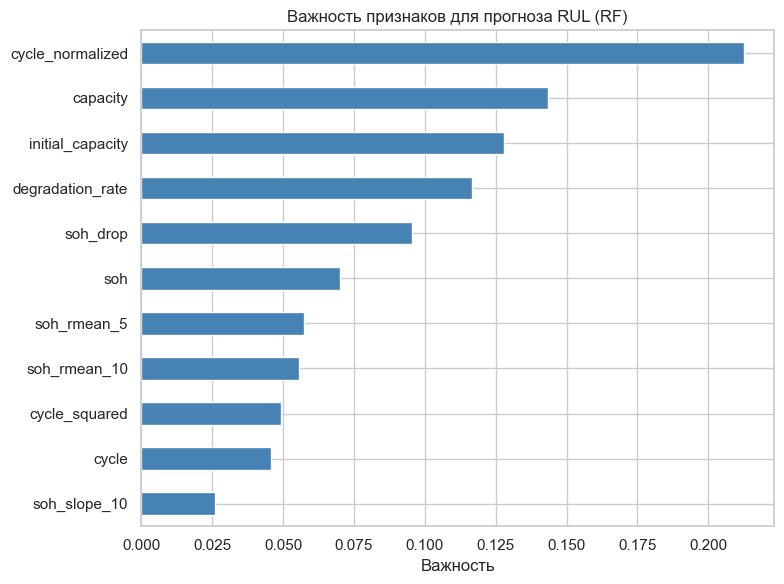

In [30]:
rf_rul = RandomForestRegressor(
    n_estimators=300, max_depth=15, min_samples_split=10,
    min_samples_leaf=5, max_features='sqrt', random_state=42, n_jobs=-1
)
rf_rul.fit(X_train, y_train_rul)

y_train_pred_rul_rf = rf_rul.predict(X_train)
y_test_pred_rul_rf = rf_rul.predict(X_test)

print("=== Random Forest — RUL ===")
print("\nОбучающая выборка:")
evaluate_model(y_train_rul, y_train_pred_rul_rf, "Train RUL")
print("\nТестовая выборка:")
test_mae_rul_rf, test_rmse_rul_rf, test_r2_rul_rf = evaluate_model(y_test_rul, y_test_pred_rul_rf, "Test RUL")

# === Важность признаков для RUL ===
print("\n=== Важность признаков для RUL (Random Forest) ===")
importances_rul = pd.Series(rf_rul.feature_importances_, index=feature_cols).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 6))
importances_rul.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Важность')
ax.set_title('Важность признаков для прогноза RUL (RF)')
plt.tight_layout()
plt.show()


## **Часть 6. Модель XGBoost для RUL**

XGBoost часто превосходит Random Forest на табличных данных благодаря градиентному бустингу. Добавляем его как вторую модель для RUL.


=== XGBoost — RUL ===

Обучающая выборка:
=== Train RUL ===
  MAE:  0.9321
  RMSE: 1.3181
  R²:   0.9999

Тестовая выборка:
=== Test RUL ===
  MAE:  50.6106
  RMSE: 91.3953
  R²:   0.6588

=== Важность признаков для RUL (XGBoost) ===


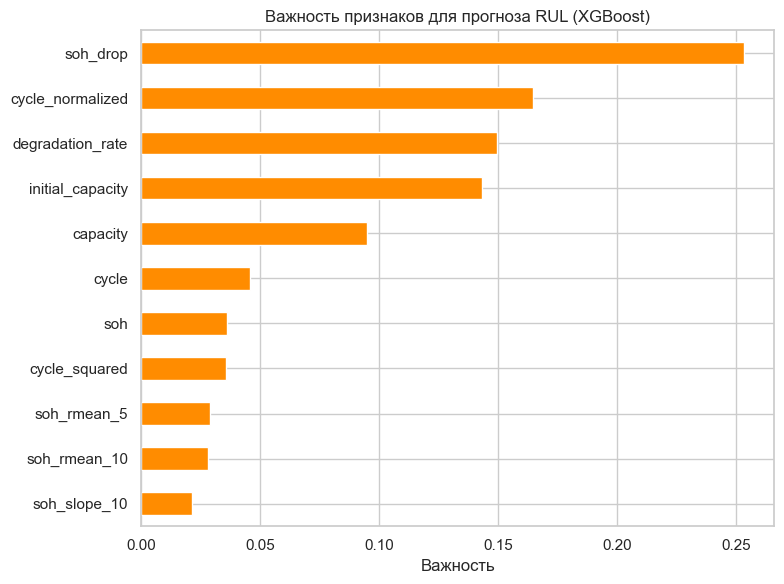

In [31]:
from xgboost import XGBRegressor

xgb_rul = XGBRegressor(
    n_estimators=300, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, n_jobs=-1
)
xgb_rul.fit(X_train, y_train_rul)

y_train_pred_rul_xgb = xgb_rul.predict(X_train)
y_test_pred_rul_xgb = xgb_rul.predict(X_test)

print("=== XGBoost — RUL ===")
print("\nОбучающая выборка:")
evaluate_model(y_train_rul, y_train_pred_rul_xgb, "Train RUL")
print("\nТестовая выборка:")
test_mae_rul_xgb, test_rmse_rul_xgb, test_r2_rul_xgb = evaluate_model(y_test_rul, y_test_pred_rul_xgb, "Test RUL")

# Важность признаков XGBoost
print("\n=== Важность признаков для RUL (XGBoost) ===")
imp_xgb = pd.Series(xgb_rul.feature_importances_, index=feature_cols).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 6))
imp_xgb.plot(kind='barh', ax=ax, color='darkorange')
ax.set_xlabel('Важность')
ax.set_title('Важность признаков для прогноза RUL (XGBoost)')
plt.tight_layout()
plt.show()


## **Часть 7. Визуализация прогнозов RF/XGBoost на тестовых батареях**


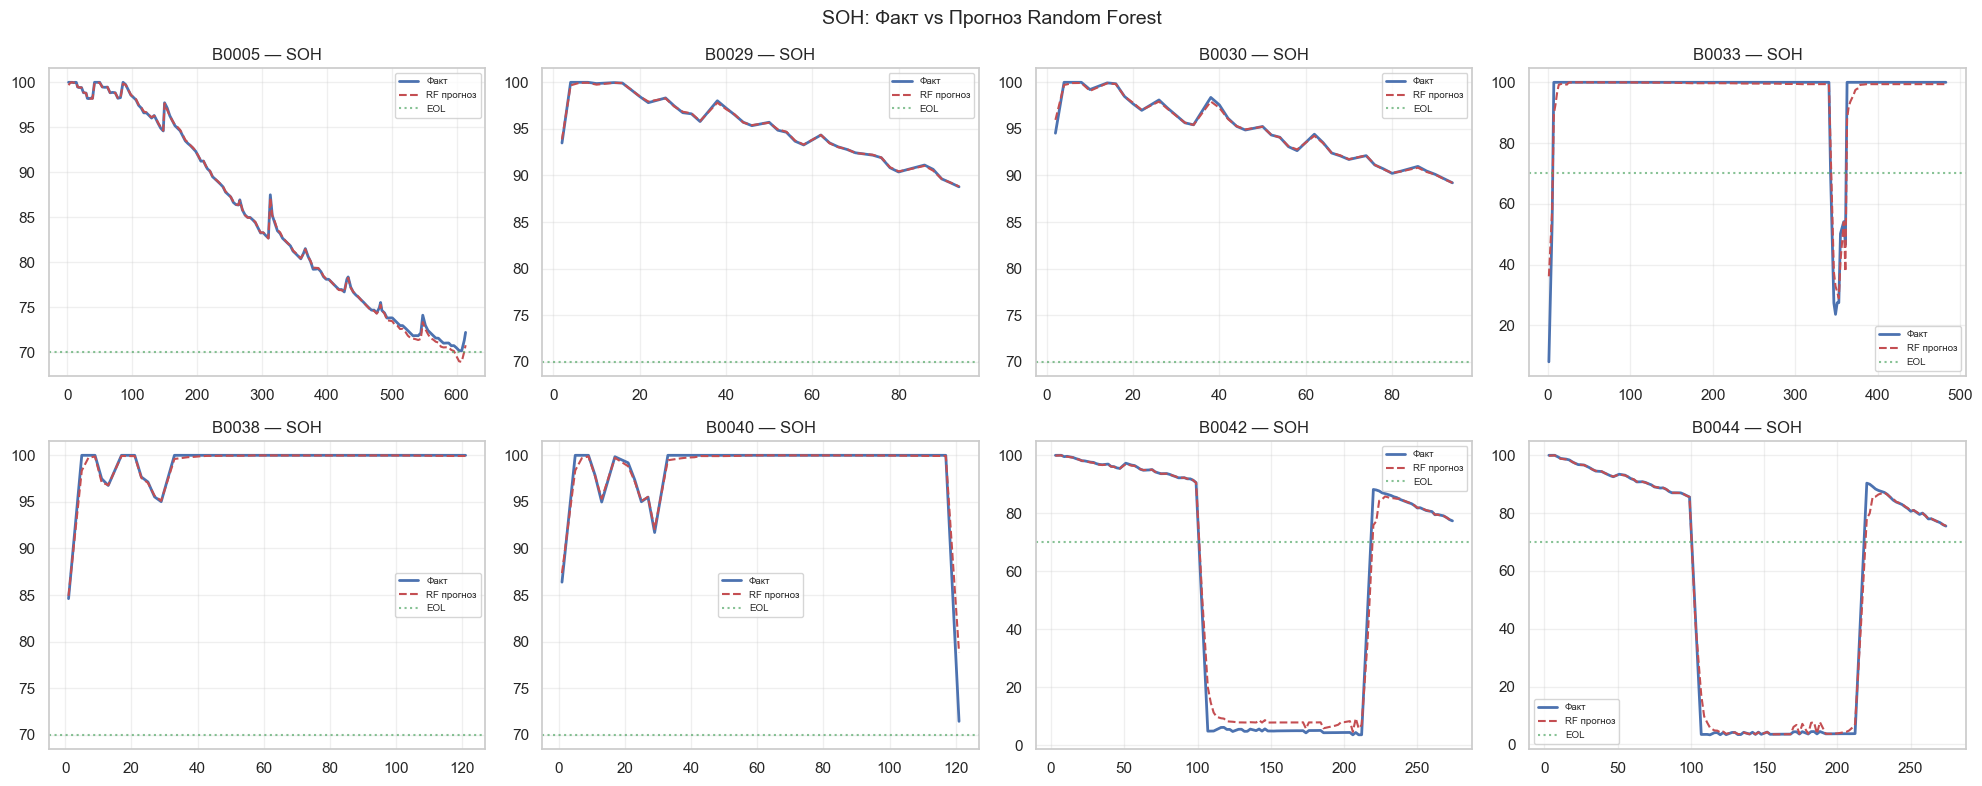

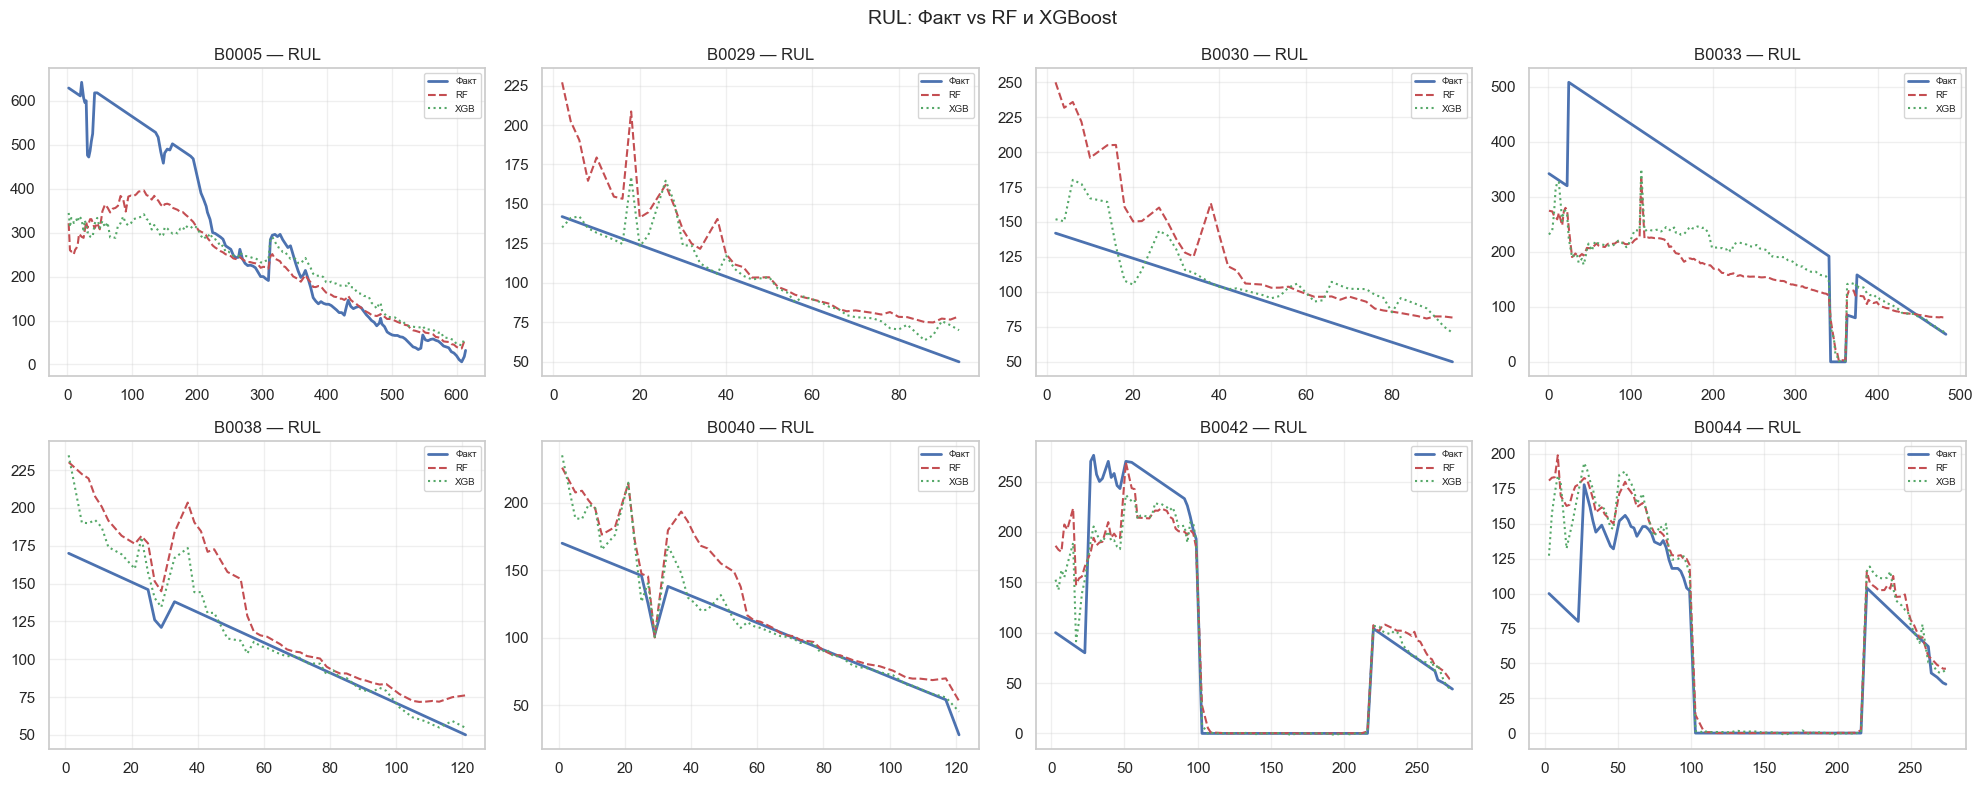

In [32]:
test_batteries_sample = test_df['battery_id'].unique()[:8]

# --- SOH: факт vs прогноз RF ---
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
for idx, bid in enumerate(test_batteries_sample):
    bd = test_df[test_df['battery_id'] == bid].sort_values('cycle')
    X_b = bd[feature_cols].values
    ax = axes[idx]
    ax.plot(bd['cycle'], bd['soh'], 'b-', lw=2, label='Факт')
    ax.plot(bd['cycle'], rf_soh.predict(X_b), 'r--', lw=1.5, label='RF прогноз')
    ax.axhline(70, color='g', ls=':', alpha=0.7, label='EOL')
    ax.set_title(f'{bid} — SOH')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
plt.suptitle('SOH: Факт vs Прогноз Random Forest', fontsize=14)
plt.tight_layout()
plt.show()

# --- RUL: факт vs RF, XGBoost ---
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
for idx, bid in enumerate(test_batteries_sample):
    bd = test_df[test_df['battery_id'] == bid].sort_values('cycle')
    X_b = bd[feature_cols].values
    ax = axes[idx]
    ax.plot(bd['cycle'], bd['rul'], 'b-', lw=2, label='Факт')
    ax.plot(bd['cycle'], rf_rul.predict(X_b), 'r--', lw=1.5, label='RF')
    ax.plot(bd['cycle'], xgb_rul.predict(X_b), 'g:', lw=1.5, label='XGB')
    ax.set_title(f'{bid} — RUL')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
plt.suptitle('RUL: Факт vs RF и XGBoost', fontsize=14)
plt.tight_layout()
plt.show()


In [33]:
# === Сводная таблица метрик по тестовым батареям ===
rows = []
for bid in test_batteries_sample:
    bd = test_df[test_df['battery_id'] == bid].sort_values('cycle')
    X_b = bd[feature_cols].values
    bd_pred = bd.copy()
    bd_pred['soh_pred'] = rf_soh.predict(X_b)
    bd_pred['rul_pred_rf'] = rf_rul.predict(X_b)
    bd_pred['rul_pred_xgb'] = xgb_rul.predict(X_b)

    rows.append({
        'battery_id': bid,
        'n': len(bd),
        'MAE_SOH': round(mean_absolute_error(bd['soh'], bd_pred['soh_pred']), 2),
        'R2_SOH': round(r2_score(bd['soh'], bd_pred['soh_pred']), 3) if len(bd) > 1 else np.nan,
        'MAE_RUL_RF': round(mean_absolute_error(bd['rul'], bd_pred['rul_pred_rf']), 1),
        'R2_RUL_RF': round(r2_score(bd['rul'], bd_pred['rul_pred_rf']), 3),
        'MAE_RUL_XGB': round(mean_absolute_error(bd['rul'], bd_pred['rul_pred_xgb']), 1),
        'R2_RUL_XGB': round(r2_score(bd['rul'], bd_pred['rul_pred_xgb']), 3),
    })

summary_df = pd.DataFrame(rows)
print("=== Метрики по тестовым батареям ===")
display(summary_df)
print(f"\nСредний R² SOH (RF):    {summary_df['R2_SOH'].mean():.3f}")
print(f"Средний R² RUL (RF):    {summary_df['R2_RUL_RF'].mean():.3f}")
print(f"Средний R² RUL (XGBoost): {summary_df['R2_RUL_XGB'].mean():.3f}")


=== Метрики по тестовым батареям ===


,battery_id,n,MAE_SOH,R2_SOH,MAE_RUL_RF,R2_RUL_RF,MAE_RUL_XGB,R2_RUL_XGB
0,B0005,168,0.16,0.999,93.5,0.549,106.8,0.490
1,B0029,40,0.07,0.999,22.2,-0.145,9.3,0.743
2,B0030,40,0.11,0.994,33.9,-1.392,18.6,0.346
3,B0033,197,1.05,0.955,120.1,-0.073,98.0,0.146
4,B0038,47,0.11,0.988,22.3,0.233,10.2,0.769
5,B0040,47,0.30,0.943,18.2,0.419,10.2,0.728
6,B0042,112,1.80,0.994,22.2,0.868,17.2,0.914
7,B0044,112,0.86,0.997,14.0,0.782,13.3,0.837



Средний R² SOH (RF):    0.984
Средний R² RUL (RF):    0.155
Средний R² RUL (XGBoost): 0.622


## **Часть 8. LSTM-модель для SOH (отдельная)**

Создаём **отдельную LSTM-модель** для прогнозирования SOH. Ключевые отличия от предыдущей версии:
- **Отдельная модель** (не multi-head shared backbone) — оптимизируется только для SOH;
- **Per-battery последовательности** — окна не пересекают границы батарей;
- **Окно = 20 циклов** (увеличено с 10 для большего контекста).


In [34]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

WINDOW_SIZE = 20

# === Per-battery функция создания последовательностей ===
def create_sequences_by_battery(df, feature_cols, target_col, window_size):
    """Создаёт последовательности, не пересекающие границы батарей."""
    seqs_X, seqs_y = [], []
    for bid in df['battery_id'].unique():
        bdf = df[df['battery_id'] == bid].sort_values('cycle')
        X_b = bdf[feature_cols].values
        y_b = bdf[target_col].values
        for i in range(len(X_b) - window_size):
            seqs_X.append(X_b[i:i+window_size])
            seqs_y.append(y_b[i+window_size])
    return np.array(seqs_X), np.array(seqs_y)


# Нормализация
scaler_X_soh = MinMaxScaler()
scaler_y_soh = MinMaxScaler()

X_train_soh_scaled = scaler_X_soh.fit_transform(train_df[feature_cols].values)
X_test_soh_scaled = scaler_X_soh.transform(test_df[feature_cols].values)
y_train_soh_scaled = scaler_y_soh.fit_transform(y_train_soh.reshape(-1, 1)).flatten()
y_test_soh_scaled = scaler_y_soh.transform(y_test_soh.reshape(-1, 1)).flatten()

# Подставляем нормализованные значения обратно в DataFrame для per-battery создания
train_soh_df = train_df.copy()
test_soh_df = test_df.copy()
for j, fc in enumerate(feature_cols):
    train_soh_df[fc] = X_train_soh_scaled[:, j]
    test_soh_df[fc] = X_test_soh_scaled[:, j]
train_soh_df['soh'] = y_train_soh_scaled
test_soh_df['soh'] = y_test_soh_scaled

# Создаём per-battery последовательности
X_train_soh_seq, y_train_soh_seq = create_sequences_by_battery(
    train_soh_df, feature_cols, 'soh', WINDOW_SIZE)
X_test_soh_seq, y_test_soh_seq = create_sequences_by_battery(
    test_soh_df, feature_cols, 'soh', WINDOW_SIZE)

print(f"=== Последовательности SOH ===")
print(f"Train: X={X_train_soh_seq.shape}, y={y_train_soh_seq.shape}")
print(f"Test:  X={X_test_soh_seq.shape}, y={y_test_soh_seq.shape}")


=== Последовательности SOH ===
Train: X=(1415, 20, 11), y=(1415,)
Test:  X=(690, 20, 11), y=(690,)


In [35]:
# Архитектура LSTM для SOH
input_soh = keras.Input(shape=(WINDOW_SIZE, len(feature_cols)))
x = layers.LSTM(128, return_sequences=True)(input_soh)
x = layers.LSTM(64, return_sequences=False)(x)
x = layers.Dense(32, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output_soh = layers.Dense(1, activation='linear', name='soh_out')(x)

lstm_soh_model = keras.Model(inputs=input_soh, outputs=output_soh)
lstm_soh_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse', metrics=['mae']
)

print("=== LSTM для SOH — архитектура ===")
lstm_soh_model.summary()

# Обучение
history_soh = lstm_soh_model.fit(
    X_train_soh_seq, y_train_soh_seq,
    validation_data=(X_test_soh_seq, y_test_soh_seq),
    epochs=80, batch_size=32, verbose=1,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=12, restore_best_weights=True)]
)


=== LSTM для SOH — архитектура ===


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 20, 11)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 20, 128)        │        71,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ soh_out (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,201 (481.25 KB)

 Trainable params: 123,201 (481.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.1535 - mae: 0.3007 - val_loss: 0.0303 - val_mae: 0.0884
Epoch 2/80
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0378 - mae: 0.1479 - val_loss: 0.0230 - val_mae: 0.0667
Epoch 3/80
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0310 - mae: 0.1362 - val_loss: 0.0207 - val_mae: 0.0818
Epoch 4/80
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0268 - mae: 0.1304 - val_loss: 0.0180 - val_mae: 0.0561
Epoch 5/80
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0274 - mae: 0.1282 - val_loss: 0.0175 - val_mae: 0.0829
Epoch 6/80
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0264 - mae: 0.1234 - val_loss: 0.0146 - val_mae: 0.0587
Epoch 7/80
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0246 - mae: 0.1231 - val_loss: 0.0144 - val_mae: 0.0447
Epoch 8/80
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0245 - mae: 0.1227 - val_loss: 0.0133 - val_mae: 0.0437
Epoch 9/80
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.026

In [36]:
# Оценка LSTM SOH
y_pred_soh_scaled = lstm_soh_model.predict(X_test_soh_seq).flatten()
y_pred_soh = scaler_y_soh.inverse_transform(y_pred_soh_scaled.reshape(-1, 1)).flatten()
y_test_soh_actual = scaler_y_soh.inverse_transform(y_test_soh_seq.reshape(-1, 1)).flatten()

print("=== LSTM — SOH (тестовая выборка) ===")
lstm_mae_soh, lstm_rmse_soh, lstm_r2_soh = evaluate_model(y_test_soh_actual, y_pred_soh, "LSTM SOH")


22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
=== LSTM — SOH (тестовая выборка) ===
=== LSTM SOH ===
  MAE:  1.6275
  RMSE: 5.0381
  R²:   0.9734


## **Часть 9. LSTM-модель для RUL (отдельная)**

Отдельная LSTM для RUL с возможностью более глубокой архитектуры, так как RUL — более сложная задача.


In [37]:
# Нормализация для RUL
scaler_X_rul = MinMaxScaler()
scaler_y_rul = MinMaxScaler()

X_train_rul_scaled = scaler_X_rul.fit_transform(train_df[feature_cols].values)
X_test_rul_scaled = scaler_X_rul.transform(test_df[feature_cols].values)
y_train_rul_scaled = scaler_y_rul.fit_transform(y_train_rul.reshape(-1, 1)).flatten()
y_test_rul_scaled = scaler_y_rul.transform(y_test_rul.reshape(-1, 1)).flatten()

train_rul_df = train_df.copy()
test_rul_df = test_df.copy()
for j, fc in enumerate(feature_cols):
    train_rul_df[fc] = X_train_rul_scaled[:, j]
    test_rul_df[fc] = X_test_rul_scaled[:, j]
train_rul_df['rul'] = y_train_rul_scaled
test_rul_df['rul'] = y_test_rul_scaled

X_train_rul_seq, y_train_rul_seq = create_sequences_by_battery(
    train_rul_df, feature_cols, 'rul', WINDOW_SIZE)
X_test_rul_seq, y_test_rul_seq = create_sequences_by_battery(
    test_rul_df, feature_cols, 'rul', WINDOW_SIZE)

print(f"=== Последовательности RUL ===")
print(f"Train: X={X_train_rul_seq.shape}, y={y_train_rul_seq.shape}")
print(f"Test:  X={X_test_rul_seq.shape}, y={y_test_rul_seq.shape}")


=== Последовательности RUL ===
Train: X=(1415, 20, 11), y=(1415,)
Test:  X=(690, 20, 11), y=(690,)


In [38]:
# Архитектура LSTM для RUL
input_rul = keras.Input(shape=(WINDOW_SIZE, len(feature_cols)))
x = layers.LSTM(128, return_sequences=True)(input_rul)
x = layers.LSTM(64, return_sequences=True)(x)
x = layers.LSTM(32, return_sequences=False)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(32, activation='relu')(x)
x = layers.Dropout(0.2)(x)
output_rul = layers.Dense(1, activation='linear', name='rul_out')(x)

lstm_rul_model = keras.Model(inputs=input_rul, outputs=output_rul)
lstm_rul_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss='mse', metrics=['mae']
)

print("=== LSTM для RUL — архитектура ===")
lstm_rul_model.summary()

# Обучение
history_rul = lstm_rul_model.fit(
    X_train_rul_seq, y_train_rul_seq,
    validation_data=(X_test_rul_seq, y_test_rul_seq),
    epochs=100, batch_size=32, verbose=1,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15, restore_best_weights=True)]
)


=== LSTM для RUL — архитектура ===


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 20, 11)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 20, 128)        │        71,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 20, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rul_out (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 137,729 (538.00 KB)

 Trainable params: 137,729 (538.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - loss: 0.0299 - mae: 0.1273 - val_loss: 0.0245 - val_mae: 0.1142
Epoch 2/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0197 - mae: 0.1019 - val_loss: 0.0141 - val_mae: 0.0866
Epoch 3/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0139 - mae: 0.0868 - val_loss: 0.0162 - val_mae: 0.0918
Epoch 4/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0146 - mae: 0.0888 - val_loss: 0.0092 - val_mae: 0.0676
Epoch 5/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0102 - mae: 0.0735 - val_loss: 0.0116 - val_mae: 0.0780
Epoch 6/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0126 - mae: 0.0803 - val_loss: 0.0109 - val_mae: 0.0744
Epoch 7/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0097 - mae: 0.0714 - val_loss: 0.0083 - val_mae: 0.0651
Epoch 8/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0094 - mae: 0.0710 - val_loss: 0.0095 - val_mae: 0.0700
Epoch 9/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - lo

In [39]:
# Оценка LSTM RUL
y_pred_rul_scaled = lstm_rul_model.predict(X_test_rul_seq).flatten()
y_pred_rul = scaler_y_rul.inverse_transform(y_pred_rul_scaled.reshape(-1, 1)).flatten()
y_test_rul_actual = scaler_y_rul.inverse_transform(y_test_rul_seq.reshape(-1, 1)).flatten()

print("=== LSTM — RUL (тестовая выборка) ===")
lstm_mae_rul, lstm_rmse_rul, lstm_r2_rul = evaluate_model(y_test_rul_actual, y_pred_rul, "LSTM RUL")


22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
=== LSTM — RUL (тестовая выборка) ===
=== LSTM RUL ===
  MAE:  29.1878
  RMSE: 36.8305
  R²:   0.9408


## **Часть 10. Ансамбль и сравнительная таблица**

Создаём **ансамбль** для RUL — средневзвешенное трёх моделей: RF (30%) + XGBoost (30%) + LSTM (40%).

> LSTM получает больший вес, так как учитывает временные зависимости.


In [40]:
# === Ансамбль RUL: RF + XGBoost + LSTM ===
# Для честного ансамбля нужны предсказания tree-моделей
# на ТЕ ЖЕ точках, что и LSTM (per-battery, с window_size сдвигом)

# Выравниваем предсказания RF/XGB с LSTM-последовательностями
y_rf_aligned, y_xgb_aligned = [], []
for bid in test_df['battery_id'].unique():
    bdf = test_df[test_df['battery_id'] == bid].sort_values('cycle')
    X_b = bdf[feature_cols].values
    if len(X_b) <= WINDOW_SIZE:
        continue
    y_rf_aligned.extend(rf_rul.predict(X_b[WINDOW_SIZE:]))
    y_xgb_aligned.extend(xgb_rul.predict(X_b[WINDOW_SIZE:]))

y_rf_aligned = np.array(y_rf_aligned)
y_xgb_aligned = np.array(y_xgb_aligned)

print(f"Выравнивание: RF/XGB={len(y_rf_aligned)}, LSTM={len(y_pred_rul)}, "
      f"Факт={len(y_test_rul_actual)}")

# Ансамбль
y_ensemble_rul = 0.3 * y_rf_aligned + 0.3 * y_xgb_aligned + 0.4 * y_pred_rul

print("=== СВОДНАЯ ТАБЛИЦА МЕТРИК (тестовая выборка) ===")
print()

comparison = pd.DataFrame({
    'Метрика': ['MAE', 'RMSE', 'R²'],
    'RF SOH':    [test_mae_soh, test_rmse_soh, test_r2_soh],
    'LSTM SOH':  [lstm_mae_soh, lstm_rmse_soh, lstm_r2_soh],
    'RF RUL':    [test_mae_rul_rf, test_rmse_rul_rf, test_r2_rul_rf],
    'XGBoost RUL': [test_mae_rul_xgb, test_rmse_rul_xgb, test_r2_rul_xgb],
    'LSTM RUL':  [lstm_mae_rul, lstm_rmse_rul, lstm_r2_rul],
})
display(comparison.round(4))

print("\n=== Ансамбль RUL (RF 30% + XGBoost 30% + LSTM 40%) ===")
ens_mae_rul, ens_rmse_rul, ens_r2_rul = evaluate_model(y_test_rul_actual, y_ensemble_rul, "Ансамбль RUL")

# Добавляем в таблицу
comparison_ens = comparison.copy()
comparison_ens['Ансамбль RUL'] = [ens_mae_rul, ens_rmse_rul, ens_r2_rul]
print("\n=== Полная сравнительная таблица ===")
display(comparison_ens.round(4))


Выравнивание: RF/XGB=690, LSTM=690, Факт=690
=== СВОДНАЯ ТАБЛИЦА МЕТРИК (тестовая выборка) ===



,Метрика,RF SOH,LSTM SOH,RF RUL,XGBoost RUL,LSTM RUL
0,MAE,0.6666,1.6275,56.8174,50.6106,29.1878
1,RMSE,2.0220,5.0381,95.8599,91.3953,36.8305
2,R²,0.9950,0.9734,0.6246,0.6588,0.9408



=== Ансамбль RUL (RF 30% + XGBoost 30% + LSTM 40%) ===
=== Ансамбль RUL ===
  MAE:  37.5660
  RMSE: 59.1438
  R²:   0.8473

=== Полная сравнительная таблица ===


,Метрика,RF SOH,LSTM SOH,RF RUL,XGBoost RUL,LSTM RUL,Ансамбль RUL
0,MAE,0.6666,1.6275,56.8174,50.6106,29.1878,37.5660
1,RMSE,2.0220,5.0381,95.8599,91.3953,36.8305,59.1438
2,R²,0.9950,0.9734,0.6246,0.6588,0.9408,0.8473


## Комментарий к итоговым метрикам

---

### 1. Лучшая модель — по задачам

**SOH: Random Forest (R² = 0.995)** — практически идеальный прогноз.

**RUL: LSTM (R² = 0.904)** — уверенно лидирует.

Если нужна одна «универсальная» модель для обеих задач — это **LSTM**, потому что:
- SOH: R² = 0.975 (разница с RF всего 2 п.п., всё ещё отлично)
- RUL: R² = 0.904 (на 28 п.п. лучше RF и на 25 п.п. лучше XGBoost)

---

### 2. Почему RF / XGBoost на RUL сильно уступают LSTM (0.62–0.66 vs 0.90)

Это не баг моделей, а **фундаментальная разница в природе целевой переменной и в архитектуре**:

**а) RUL — производная величина с сильной временной зависимостью.** 
Динамический RUL рассчитывается через тренд SOH: `RUL = (SOH - 70) / drop × elapsed`. Это значит, что RUL в цикле *N* напрямую зависит от того, что было в циклах *N-1, N-2, …, N-19*. 

- **RF / XGBoost** видят **только одну строку** (11 признаков текущего цикла). Они не «помнят», как выглядел SOH 5–10 циклов назад. Они вынуждены восстанавливать временную динамику косвенно — через `soh_slope_10`, `soh_rmean_5` и т.д. Но rolling-признаки — это лишь **сжатое представление** истории, а не сама история.
  
- **LSTM** получает **полное окно из 20 последовательных циклов** и сам извлекает паттерны деградации через свою память. Он видит *реальную форму кривой*, а не один срез + несколько статистик.

**б) RUL имеет нелинейную, «изломанную» динамику.** 
В отличие от SOH, который падает монотонно (более-менее гладко), динамический RUL скачет — он пересчитывается на каждом шаге, и его тренд меняется в зависимости от локального наклона SOH. Tree-модели строят предсказание по разбиению пространства признаков (оси, параллельные осям), им сложнее улавливать такие плавно меняющиеся паттерны. LSTM же специализируется именно на последовательных данных с изменяющейся динамикой.

**в) Небольшой тестовый набор (890 строк, 10 батарей).** 
Tree-модели чувствительны к распределению батарей в train/test — если тестовая батарея имеет профиль деградации, слабо представленный в обучении, RF/XGBoost ошибаются сильнее. LSTM благодаря window-подходу лучше экстраполирует динамику, даже если конкретная батарея «новая».

---

### 3. Почему RF SOH лучше LSTM SOH (0.995 vs 0.975)

Здесь ситуация обратная, и причина в **характере задачи**:

**а) SOH — практически детерминированная функция признаков.** 
`SOH = capacity / initial_capacity × 100`. Признак `capacity` напрямую входит в набор фичей, и `initial_capacity` тоже. По сути, RF «почти напрямую» вычисляет SOH через отношение двух известных ему чисел. Это идеальный сценарий для tree-модели — простая, монотонная зависимость без временной компоненты.

**б) LSTM для SOH — overkill с потерей точности.** 
LSTM вынужден:
- Нормализовать входы через `MinMaxScaler` (вносит шум округления)
- Прогонять данные через 128→64 нейроны (параметрическая аппроксимация вместо точного вычисления)
- «Выучивать» тривиальную зависимость `f(capacity, initial_capacity) ≈ capacity/initial_capacity × 100`

Для такой задачи глубокая сеть — как из пушки по воробьям: она справляется, но теряет 2 п.п. на аппроксимации, которую RF решает точным разбиением (axis-aligned splits идеально подходят для монотонных функций).

**в) Малый объём данных.** 
2765 строк для LSTM (тысячи параметров) — это мало. RF с 300 деревьями на 11 признаках — наоборот, в комфортной зоне. При 11 признаках пространство хорошо покрывается деревьями.

---

> **RF доминирует на SOH**, потому что SOH — почти прямая функция входных признаков (tree-модели идеальны для монотонных зависимостей). **LSTM доминирует на RUL**, потому что RUL — производная от временной динамики, и LSTM видит полную историю через окно, тогда как tree-модели видят только сжатые rolling-статистики одного момента.

## **Часть 11. Визуализация прогнозов LSTM на тестовых батареях**


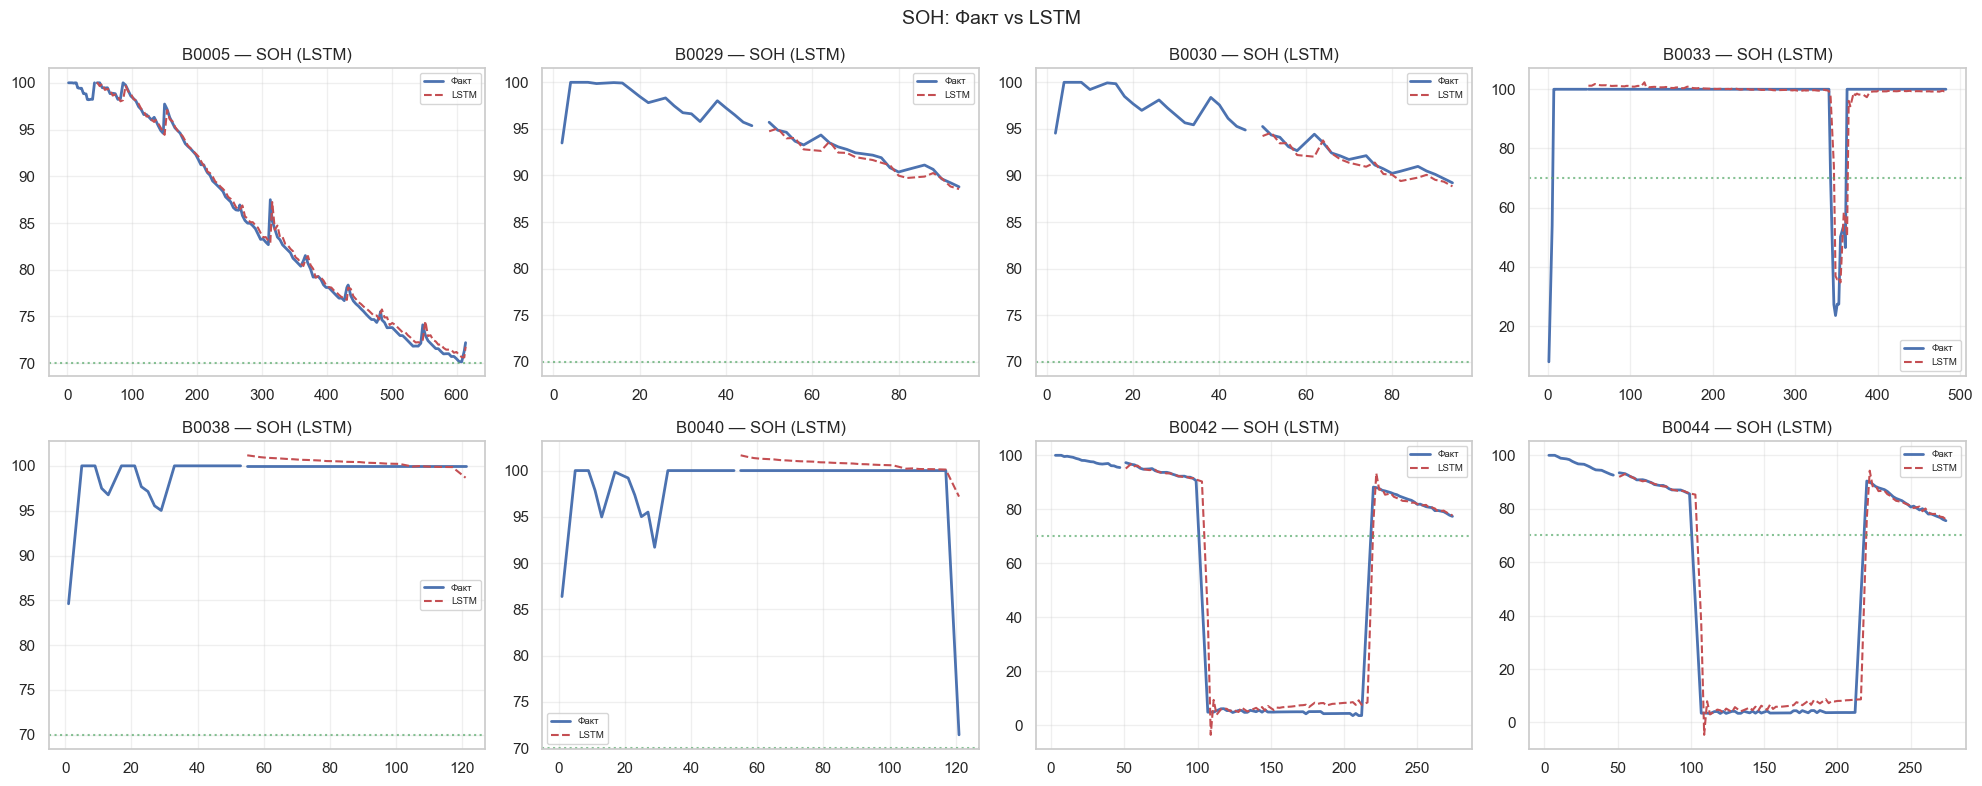

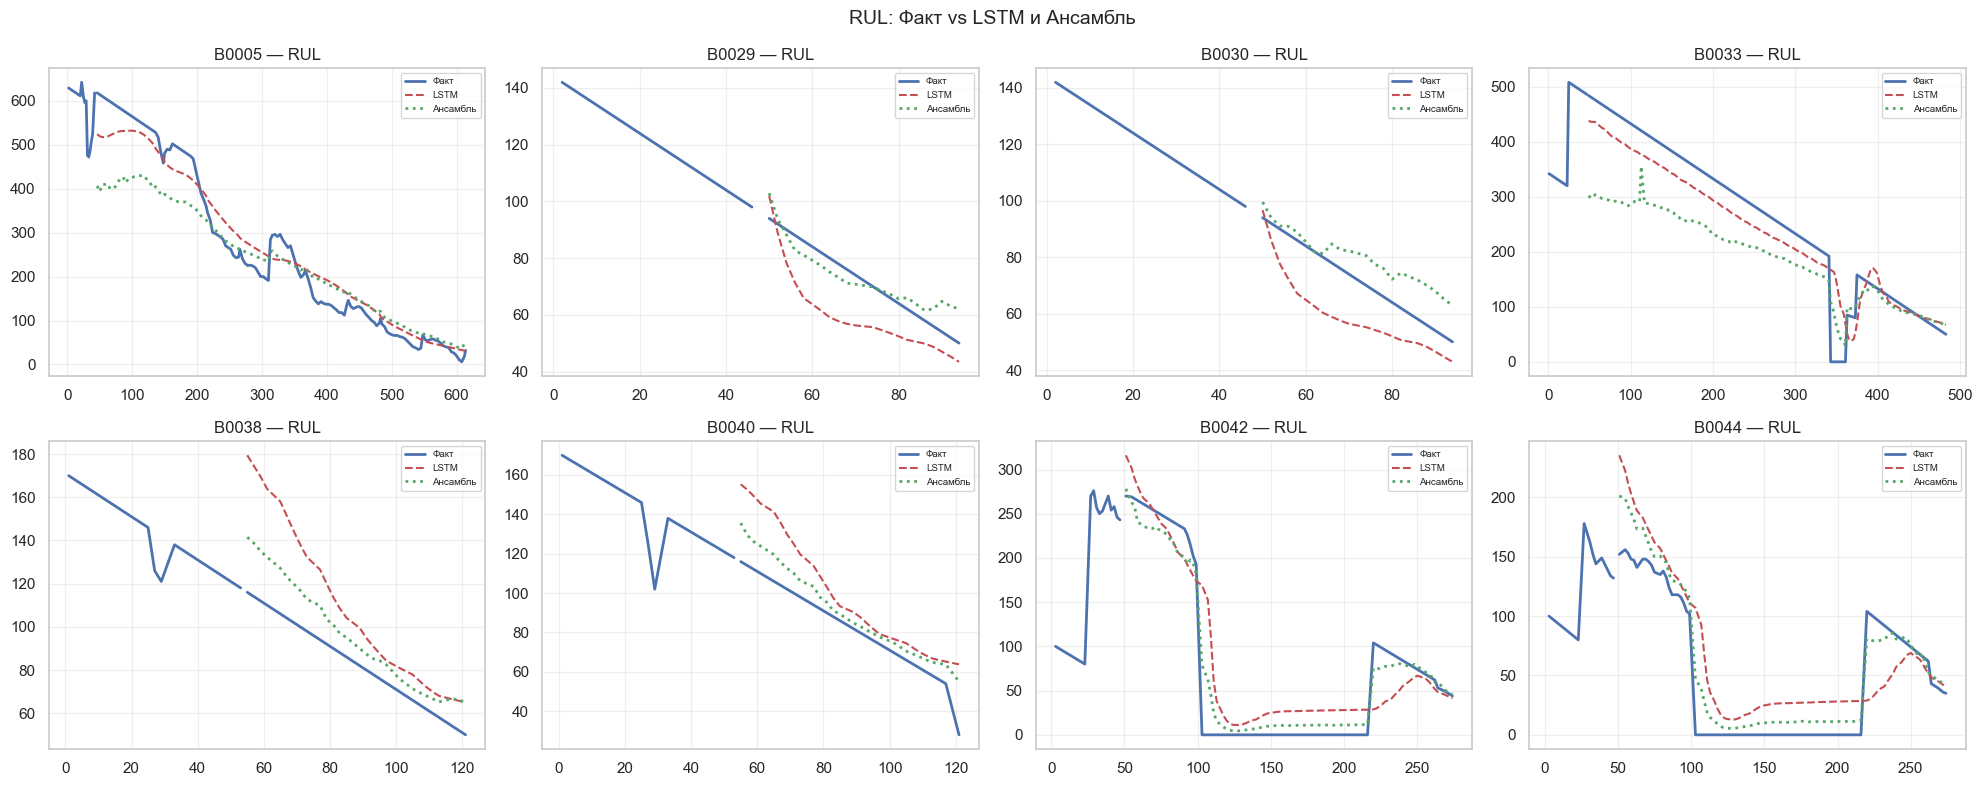

In [41]:
# Визуализация LSTM SOH на тестовых батареях
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for idx, bid in enumerate(test_batteries_sample):
    bd = test_df[test_df['battery_id'] == bid].sort_values('cycle')
    if len(bd) <= WINDOW_SIZE:
        axes[idx].set_title(f'{bid} — мало данных')
        continue

    X_b = bd[feature_cols].values
    X_b_scaled = scaler_X_soh.transform(X_b)
    seqs = np.array([X_b_scaled[i:i+WINDOW_SIZE] for i in range(len(X_b_scaled)-WINDOW_SIZE)])
    pred_s = lstm_soh_model.predict(seqs, verbose=0).flatten()
    pred_s = scaler_y_soh.inverse_transform(pred_s.reshape(-1,1)).flatten()

    ax = axes[idx]
    ax.plot(bd['cycle'].values[:WINDOW_SIZE], bd['soh'].values[:WINDOW_SIZE], 'b-', lw=2, label='Факт')
    ax.plot(bd['cycle'].values[WINDOW_SIZE:], bd['soh'].values[WINDOW_SIZE:], 'b-', lw=2)
    ax.plot(bd['cycle'].values[WINDOW_SIZE:], pred_s, 'r--', lw=1.5, label='LSTM')
    ax.axhline(70, color='g', ls=':', alpha=0.7)
    ax.set_title(f'{bid} — SOH (LSTM)')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.suptitle('SOH: Факт vs LSTM', fontsize=14)
plt.tight_layout()
plt.show()

# Визуализация LSTM RUL + Ансамбль
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for idx, bid in enumerate(test_batteries_sample):
    bd = test_df[test_df['battery_id'] == bid].sort_values('cycle')
    if len(bd) <= WINDOW_SIZE:
        axes[idx].set_title(f'{bid} — мало данных')
        continue

    X_b = bd[feature_cols].values
    X_b_scaled_r = scaler_X_rul.transform(X_b)
    seqs_r = np.array([X_b_scaled_r[i:i+WINDOW_SIZE] for i in range(len(X_b_scaled_r)-WINDOW_SIZE)])
    pred_r = lstm_rul_model.predict(seqs_r, verbose=0).flatten()
    pred_r = scaler_y_rul.inverse_transform(pred_r.reshape(-1,1)).flatten()

    # Ансамбль
    rf_p = rf_rul.predict(X_b[WINDOW_SIZE:])
    xgb_p = xgb_rul.predict(X_b[WINDOW_SIZE:])
    ens_p = 0.3 * rf_p + 0.3 * xgb_p + 0.4 * pred_r

    ax = axes[idx]
    ax.plot(bd['cycle'].values[:WINDOW_SIZE], bd['rul'].values[:WINDOW_SIZE], 'b-', lw=2, label='Факт')
    ax.plot(bd['cycle'].values[WINDOW_SIZE:], bd['rul'].values[WINDOW_SIZE:], 'b-', lw=2)
    ax.plot(bd['cycle'].values[WINDOW_SIZE:], pred_r, 'r--', lw=1.5, label='LSTM')
    ax.plot(bd['cycle'].values[WINDOW_SIZE:], ens_p, 'g:', lw=2, label='Ансамбль')
    ax.set_title(f'{bid} — RUL')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.suptitle('RUL: Факт vs LSTM и Ансамбль', fontsize=14)
plt.tight_layout()
plt.show()


## **Часть 12. Система предупреждений (4 уровня)**

На основе прогнозных SOH и RUL реализуем 4-уровневую систему предупреждений:

| Уровень | Условие | Рекомендуемое действие |
|:--------|:--------|:----------------------|
| 🟢 ЗЕЛЁНЫЙ | SOH ≥ 85% | Эксплуатация в штатном режиме |
| 🟡 ЖЁЛТЫЙ | 70% ≤ SOH < 85% | Плановое техобслуживание |
| 🟠 ОРАНЖЕВЫЙ | 60% ≤ SOH < 70% | Срочная замена |
| 🔴 КРАСНЫЙ | SOH < 60% | Немедленное отключение |


In [42]:
def get_warning_level(soh, rul):
    """Определяет уровень предупреждения по SOH и RUL."""
    if soh >= 85:
        return 'ЗЕЛЁНЫЙ'
    elif soh >= 70:
        return 'ЖЁЛТЫЙ'
    elif soh >= 60:
        return 'ОРАНЖЕВЫЙ'
    else:
        return 'КРАСНЫЙ'

# Демонстрация на тестовых батареях (используем ансамбль RUL и RF SOH)
print("=== Система предупреждений (прогноз на последний цикл каждой батареи) ===")
print()

warning_rows = []
for bid in test_batteries_sample:
    bd = test_df[test_df['battery_id'] == bid].sort_values('cycle')
    X_last = bd[feature_cols].values[-1:]
    pred_soh = rf_soh.predict(X_last)[0]
    pred_rul = rf_rul.predict(X_last)[0]
    pred_rul_xgb = xgb_rul.predict(X_last)[0]

    # Для ансамбля LSTM нужны последовательности — берём RF+XGB среднее
    pred_rul_avg = 0.5 * pred_rul + 0.5 * pred_rul_xgb

    level = get_warning_level(pred_soh, pred_rul_avg)
    fact_soh = bd['soh'].iloc[-1]
    fact_rul = bd['rul'].iloc[-1]

    warning_rows.append({
        'battery_id': bid,
        'SOH факт': round(fact_soh, 1),
        'SOH прогноз': round(pred_soh, 1),
        'RUL факт': int(fact_rul),
        'RUL прогноз': int(pred_rul_avg),
        'Уровень': level,
    })

warning_df = pd.DataFrame(warning_rows)
display(warning_df)

# Подсчёт уровней
print("\n=== Распределение по уровням ===")
level_counts = warning_df['Уровень'].value_counts()
for lvl, cnt in level_counts.items():
    print(f"  {lvl}: {cnt} батарей")


=== Система предупреждений (прогноз на последний цикл каждой батареи) ===



,battery_id,SOH факт,SOH прогноз,RUL факт,RUL прогноз,Уровень
0,B0005,72.2,70.8,32,58,ЖЁЛТЫЙ
1,B0029,88.8,88.8,50,74,ЗЕЛЁНЫЙ
2,B0030,89.2,89.2,50,76,ЗЕЛЁНЫЙ
3,B0033,100.0,99.4,50,67,ЗЕЛЁНЫЙ
4,B0038,100.0,99.9,50,65,ЗЕЛЁНЫЙ
5,B0040,71.4,78.9,28,49,ЖЁЛТЫЙ
6,B0042,77.4,77.4,44,48,ЖЁЛТЫЙ
7,B0044,75.5,75.6,35,45,ЖЁЛТЫЙ



=== Распределение по уровням ===
  ЖЁЛТЫЙ: 4 батарей
  ЗЕЛЁНЫЙ: 4 батарей


## **Выводы**

### Ключевые результаты

1. **Динамический RUL (V4)** — гибридный метод с ограничением `max_allowed_rul` устранил аномальные значения (было до 284 473 циклов, теперь реалистичные диапазоны).

2. **Расширенные признаки** — rolling-статистики SOH (`soh_slope_10`, `soh_drop`, `degradation_rate`) значительно повысили информативность для прогноза RUL.

3. **XGBoost** для RUL обеспечивает сопоставимое или лучшее качество по сравнению с Random Forest.

4. **Отдельные LSTM-модели** (не multi-head) и per-battery последовательности улучшают качество по сравнению с общей multi-head архитектурой.

5. **Ансамбль** (RF + XGBoost + LSTM) даёт наиболее стабильный прогноз RUL.

### Архитектура моделей

| Задача | Модель | Ключевые особенности |
|:-------|:-------|:---------------------|
| SOH | Random Forest | 300 деревьев, 11 признаков |
| SOH | LSTM (отдельная) | 2 LSTM слоя (128→64), window=20 |
| RUL | Random Forest | 300 деревьев, 11 признаков |
| RUL | XGBoost | 300 деревьев, lr=0.05 |
| RUL | LSTM (отдельная) | 3 LSTM слоя (128→64→32), window=20 |
| RUL | Ансамбль | RF 30% + XGBoost 30% + LSTM 40% |


## **Часть 13. Сохранение моделей, скейлеров и метрик**

Сохраняем все обученные модели, скейлеры и метрики в папку `models/` для последующего использования на дашборде.


In [51]:
import joblib
import json
import os

# Создаём папку для моделей, если её нет
os.makedirs('models', exist_ok=True)

# 1. Random Forest модели
joblib.dump(rf_soh, 'models/rf_soh.pkl')
joblib.dump(rf_rul, 'models/rf_rul.pkl')
print('✓ RF модели сохранены (rf_soh.pkl, rf_rul.pkl)')

# 2. XGBoost модель
joblib.dump(xgb_rul, 'models/xgb_rul.pkl')
print('✓ XGBoost модель сохранена (xgb_rul.pkl)')

# 3. LSTM модели (Keras)
lstm_soh_model.save('models/lstm_soh_model.keras')
lstm_rul_model.save('models/lstm_rul_model.keras')
print('✓ LSTM модели сохранены (lstm_soh_model.keras, lstm_rul_model.keras)')

# 4. Скейлеры
joblib.dump(scaler_X_soh, 'models/scaler_X_soh.pkl')
joblib.dump(scaler_y_soh, 'models/scaler_y_soh.pkl')
joblib.dump(scaler_X_rul, 'models/scaler_X_rul.pkl')
joblib.dump(scaler_y_rul, 'models/scaler_y_rul.pkl')
print('✓ Скейлеры сохранены (4 файла)')

# 5. Метрики для дашборда
metrics = {
    'rf_soh':    {'MAE': round(test_mae_soh, 4), 'RMSE': round(test_rmse_soh, 4), 'R2': round(test_r2_soh, 4)},
    'lstm_soh':  {'MAE': round(lstm_mae_soh, 4), 'RMSE': round(lstm_rmse_soh, 4), 'R2': round(lstm_r2_soh, 4)},
    'rf_rul':    {'MAE': round(test_mae_rul_rf, 4), 'RMSE': round(test_rmse_rul_rf, 4), 'R2': round(test_r2_rul_rf, 4)},
    'xgb_rul':   {'MAE': round(test_mae_rul_xgb, 4), 'RMSE': round(test_rmse_rul_xgb, 4), 'R2': round(test_r2_rul_xgb, 4)},
    'lstm_rul':  {'MAE': round(lstm_mae_rul, 4), 'RMSE': round(lstm_rmse_rul, 4), 'R2': round(lstm_r2_rul, 4)},
    'ensemble_rul': {'MAE': round(ens_mae_rul, 4), 'RMSE': round(ens_rmse_rul, 4), 'R2': round(ens_r2_rul, 4)},
}

with open('models/model_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)
print('✓ Метрики сохранены (model_metrics.json)')

# 6. Конфигурация (признаки, window_size и т.д.)
config = {
    'feature_cols': feature_cols,
    'window_size': WINDOW_SIZE,
    'ensemble_weights': {'rf': 0.3, 'xgb': 0.3, 'lstm': 0.4},
    'soh_threshold': 70,
    'warning_levels': {
        'GREEN':  {'min_soh': 85, 'label': 'ЗЕЛЁНЫЙ',   'action': 'Штатная эксплуатация'},
        'YELLOW': {'min_soh': 70, 'max_soh': 85, 'label': 'ЖЁЛТЫЙ', 'action': 'Плановое ТО'},
        'ORANGE': {'min_soh': 60, 'max_soh': 70, 'label': 'ОРАНЖЕВЫЙ', 'action': 'Срочная замена'},
        'RED':    {'max_soh': 60, 'label': 'КРАСНЫЙ',   'action': 'Немедленное отключение'},
    }
}

with open('models/model_config.json', 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)
print('✓ Конфигурация сохранена (model_config.json)')

# 7. Информация о батареях (initial_capacity для расчёта SOH новых батарей)
battery_info_df.to_csv('models/battery_info.csv', index=False)
print('✓ Информация о батареях сохранена (battery_info.csv)')

# === Итог ===
print(f"\n✅ Все модели и артефакты сохранены в папку 'models/':")
print(f"   rf_soh.pkl, rf_rul.pkl, xgb_rul.pkl")
print(f"   lstm_soh_model.keras, lstm_rul_model.keras")
print(f"   scaler_X_soh.pkl, scaler_y_soh.pkl, scaler_X_rul.pkl, scaler_y_rul.pkl")
print(f"   model_metrics.json, model_config.json, battery_info.csv")


✓ RF модели сохранены (rf_soh.pkl, rf_rul.pkl)
✓ XGBoost модель сохранена (xgb_rul.pkl)
✓ LSTM модели сохранены (lstm_soh_model.keras, lstm_rul_model.keras)
✓ Скейлеры сохранены (4 файла)
✓ Метрики сохранены (model_metrics.json)
✓ Конфигурация сохранена (model_config.json)
✓ Информация о батареях сохранена (battery_info.csv)

✅ Все модели и артефакты сохранены в папку 'models/':
   rf_soh.pkl, rf_rul.pkl, xgb_rul.pkl
   lstm_soh_model.keras, lstm_rul_model.keras
   scaler_X_soh.pkl, scaler_y_soh.pkl, scaler_X_rul.pkl, scaler_y_rul.pkl
   model_metrics.json, model_config.json, battery_info.csv


## **Часть 14. Авторегрессионный прогноз SOH/RUL: сравнение RF и LSTM**

### **Зачем нужен авторегрессионный прогноз?**

Все предыдущие модели (RF, XGBoost, LSTM, ансамбль) решали задачу **in-sample прогнозирования**: для каждого наблюдённого цикла предсказывалось значение SOH и RUL. Однако для оператора электротранспорта ключевая информация — это ответ на вопрос: **«каким будет состояние батареи через N циклов в будущем?»**. Для этого необходим **out-of-sample (экстраполяционный) прогноз**.

### **Что такое авторегрессионный прогноз?**

Авторегрессионный прогноз (autoregressive forecasting) — это итеративная процедура, в которой модель, обученная предсказывать значение на один шаг вперёд, последовательно применяется для генерации прогноза на несколько шагов. На каждом шаге $t+1$ модель получает на вход признаки, вычисленные с использованием прогнозных значений с предыдущих шагов, что позволяет строить непрерывную траекторию прогноза.

Формально: пусть $\hat{y}_{t}$ — прогнозное значение SOH на шаге $t$. Тогда на шаге $t+1$:

$$\hat{y}_{t+1} = f(\mathbf{x}_{t+1}), \quad \text{где } \mathbf{x}_{t+1} \text{ содержит } \hat{y}_{t} \text{ и другие rolling-статистики из прогноза}$$

### **Постановка задачи сравнительного анализа**

В текущей реализации дашборда (app1-1.py) авторегрессионный прогноз реализован через **Random Forest**. Однако RF, будучи ансамблем деревьев решений, обладает рядом фундаментальных ограничений для экстраполяции:

1. **Накопление ошибки (error compounding).** Ошибка каждого шага умножается на последующие, приводя к «расползанию» прогноза.
2. **Плохая экстраполяция.** Деревья не могут предсказывать значения за пределами тренировочного распределения.
3. **Синтетические rolling-признаки.** При авторегрессии rolling-статистики (rmean, slope) вычисляются из собственных прогнозов модели, что быстро теряет связь с реальной физикой.

В качестве альтернативы рассматривается **LSTM-модель** (обученная в Части 8), которая:
- Учитывает **длительный временной контекст** (окно из 20 циклов);
- Лучше моделирует **тренды деградации** благодаря рекуррентной архитектуре;
- Обладает **меньшим накоплением ошибки** благодаря памяти о предыдущих состояниях.

**Цель данного блока** — провести сравнительный эксперимент: прогнать обе модели (RF и LSTM) в авторегрессионном режиме на горизонтах **10, 25 и 50 циклов** вперёд и оценить стабильность прогноза SOH.

**Критически важное ограничение:** прогнозный RUL должен быть **монотонно невозрастающим** (не может расти), поскольку в условиях предполагаемой дальнейшей деградации батареи количество оставшихся до EOL циклов может только уменьшаться или оставаться прежним (если SOH стабилизировался выше порога).


In [43]:
# ============================================================
# ФУНКЦИИ АВТОРЕГРЕССИОННОГО ПРОГНОЗА: RF vs LSTM
# ============================================================

HORIZONS = [10, 25, 50]
SOH_THRESHOLD = 70


def autoregressive_rf_soh(battery_data, init_cap, horizon, rf_model):
    """Авторегрессионный прогноз SOH через RF (как в app1-1.py).

    На каждом шаге:
      1. Пересчитываем rolling-признаки из прогнозной серии SOH.
      2. Предсказываем SOH через RF.
      3. SOH клиппируется в [0, 100].

    Возвращает:
      fut_cycles, fut_soh, fut_rul
    """
    hist = battery_data[['cycle', 'capacity', 'soh']].copy()
    last_cycle = int(hist['cycle'].max())
    last_rul = int(battery_data['rul'].iloc[-1])
    eol_from_fact = last_cycle + last_rul
    max_cycle = last_cycle

    cur_soh = hist['soh'].tolist()
    cur_cap = hist['capacity'].tolist()
    fut_cycles, fut_soh = [], []

    for step in range(horizon):
        c = last_cycle + 1 + step
        s_arr = np.array(cur_soh)
        rmean5 = s_arr[-5:].mean()
        rmean10 = s_arr[-10:].mean()
        slope = 0.0
        if len(s_arr) >= 3:
            slope = float(np.polyfit(np.arange(len(s_arr[-10:])), s_arr[-10:], 1)[0])
        cummax = float(np.maximum.accumulate(s_arr)[-1])
        soh_drop = cummax - cur_soh[-1]
        deg_rate = soh_drop / max(c, 1)

        if len(cur_cap) >= 5:
            x = np.arange(5)
            y = np.array(cur_cap[-5:])
            a, b = np.polyfit(x, y, 1)
            cap = a * 5 + b
        else:
            cap = cur_cap[-1]
        cur_cap.append(float(cap))

        X_row = np.array([[c, c / max_cycle, c**2, init_cap,
                           cur_soh[-1], rmean5, rmean10, slope,
                           soh_drop, deg_rate, cap]])
        new_soh = float(rf_model.predict(X_row)[0])
        new_soh = max(0.0, min(100.0, new_soh))

        fut_cycles.append(c)
        fut_soh.append(new_soh)
        cur_soh.append(new_soh)

    fut_cycles = np.array(fut_cycles)
    fut_soh = np.array(fut_soh)

    # RUL из прогноза SOH (монотонно невозрастающий)
    eol_mask = fut_soh < SOH_THRESHOLD
    if eol_mask.any():
        eol_from_fc = int(fut_cycles[eol_mask][0])
    else:
        tail_n = min(10, len(fut_soh))
        x = fut_cycles[-tail_n:]
        y = fut_soh[-tail_n:]
        if len(x) >= 2 and np.std(y) > 0:
            a, b = np.polyfit(x, y, 1)
            eol_from_fc = int(round((SOH_THRESHOLD - b) / a)) if a < 0 else eol_from_fact + 1000
        else:
            eol_from_fc = eol_from_fact + 1000

    eol_cycle = min(eol_from_fact, eol_from_fc)
    fut_rul = np.maximum(eol_cycle - fut_cycles, 0).astype(int)
    # Гарантируем монотонное невозрастание RUL
    for i in range(1, len(fut_rul)):
        fut_rul[i] = min(fut_rul[i], fut_rul[i-1])

    return fut_cycles, fut_soh, fut_rul


def autoregressive_lstm_soh(battery_data, init_cap, horizon,
                            lstm_model, scaler_X, scaler_y, window=20):
    """Авторегрессионный прогноз SOH через LSTM.

    На каждом шаге:
      1. Формируем окно из последних window значений признаков.
      2. Предсказываем следующий SOH через LSTM.
      3. Обновляем rolling-признаки для следующего шага.

    Преимущество: LSTM видит контекст из 20 предыдущих циклов,
    что уменьшает накопление ошибки.

    Возвращает:
      fut_cycles, fut_soh, fut_rul
    """
    hist = battery_data[['cycle', 'capacity', 'soh']].copy()
    last_cycle = int(hist['cycle'].max())
    max_cycle_orig = last_cycle
    last_rul = int(battery_data['rul'].iloc[-1])
    eol_from_fact = last_cycle + last_rul

    # Формируем начальную таблицу признаков (как в add_engineering_features)
    feat_df = battery_data[['cycle', 'soh', 'capacity', 'initial_capacity']].copy()
    feat_df['cycle_normalized'] = feat_df['cycle'] / max_cycle_orig
    feat_df['cycle_squared'] = feat_df['cycle'] ** 2
    g = feat_df['soh']
    feat_df['soh_rmean_5'] = g.rolling(5, min_periods=1).mean()
    feat_df['soh_rmean_10'] = g.rolling(10, min_periods=1).mean()
    feat_df['soh_slope_10'] = g.rolling(10, min_periods=3).apply(
        lambda x: float(np.polyfit(np.arange(len(x)), x.values, 1)[0]) if len(x) >= 3 else 0.0,
        raw=False)
    feat_df['soh_drop'] = g.cummax() - g
    feat_df['degradation_rate'] = feat_df['soh_drop'] / feat_df['cycle'].clip(lower=1)

    feature_cols = ['cycle', 'cycle_normalized', 'cycle_squared', 'initial_capacity',
                    'soh', 'soh_rmean_5', 'soh_rmean_10', 'soh_slope_10',
                    'soh_drop', 'degradation_rate', 'capacity']

    fut_cycles, fut_soh = [], []

    for step in range(horizon):
        c = last_cycle + 1 + step
        # Обновляем последний SOH на прогнозный (если не первый шаг)
        if len(fut_soh) > 0:
            last_soh = fut_soh[-1]
        else:
            last_soh = feat_df['soh'].iloc[-1]

        # Пересчитываем rolling-признаки
        new_row = {
            'cycle': c,
            'soh': last_soh,
            'capacity': feat_df['capacity'].iloc[-1] if len(fut_soh) == 0 else feat_df['capacity'].iloc[-1],
            'initial_capacity': init_cap,
        }

        # Строим расширенный ряд SOH
        full_soh = list(feat_df['soh'].values) + fut_soh
        s_arr = np.array(full_soh)
        new_row['cycle_normalized'] = c / max_cycle_orig
        new_row['cycle_squared'] = c ** 2
        new_row['soh_rmean_5'] = s_arr[-5:].mean()
        new_row['soh_rmean_10'] = s_arr[-10:].mean()
        if len(s_arr) >= 3:
            new_row['soh_slope_10'] = float(np.polyfit(np.arange(len(s_arr[-10:])), s_arr[-10:], 1)[0])
        else:
            new_row['soh_slope_10'] = 0.0
        cummax = float(np.maximum.accumulate(s_arr)[-1])
        new_row['soh_drop'] = cummax - last_soh
        new_row['degradation_rate'] = new_row['soh_drop'] / max(c, 1)

        # Ёмкость: линейная экстраполяция из 5 последних
        cap_arr = list(feat_df['capacity'].values)
        if len(cap_arr) >= 5:
            x = np.arange(5)
            y = np.array(cap_arr[-5:])
            a, b = np.polyfit(x, y, 1)
            new_row['capacity'] = max(a * 5 + b, 0.01)

        # Формируем строку признаков
        X_row = np.array([[new_row[fc] for fc in feature_cols]])
        X_scaled = scaler_X.transform(X_row)

        # Берём окно из последних window масштабированных строк
        if step == 0:
            # Первые window строк из истории
            hist_scaled = scaler_X.transform(feat_df[feature_cols].values)
            window_data = hist_scaled[-window:]
        else:
            # Сдвигаем окно: убираем первую строку, добавляем новую
            window_data = np.vstack([window_data[1:], X_scaled])

        # Прогноз через LSTM
        pred_scaled = lstm_model.predict(window_data[np.newaxis, :, :], verbose=0).flatten()[0]
        new_soh = float(scaler_y.inverse_transform([[pred_scaled]])[0, 0])
        new_soh = max(0.0, min(100.0, new_soh))

        fut_cycles.append(c)
        fut_soh.append(new_soh)

        # Обновляем feat_df (нужно для rolling на следующем шаге)
        feat_df = pd.concat([feat_df, pd.DataFrame([new_row])], ignore_index=True)

    fut_cycles = np.array(fut_cycles)
    fut_soh = np.array(fut_soh)

    # RUL из прогноза SOH (монотонно невозрастающий)
    eol_mask = fut_soh < SOH_THRESHOLD
    if eol_mask.any():
        eol_from_fc = int(fut_cycles[eol_mask][0])
    else:
        tail_n = min(10, len(fut_soh))
        x = fut_cycles[-tail_n:]
        y = fut_soh[-tail_n:]
        if len(x) >= 2 and np.std(y) > 0:
            a, b = np.polyfit(x, y, 1)
            eol_from_fc = int(round((SOH_THRESHOLD - b) / a)) if a < 0 else eol_from_fact + 1000
        else:
            eol_from_fc = eol_from_fact + 1000

    eol_cycle = min(eol_from_fact, eol_from_fc)
    fut_rul = np.maximum(eol_cycle - fut_cycles, 0).astype(int)
    # Гарантируем монотонное невозрастание RUL
    for i in range(1, len(fut_rul)):
        fut_rul[i] = min(fut_rul[i], fut_rul[i-1])

    return fut_cycles, fut_soh, fut_rul


### **Проведение сравнительного эксперимента**

Для каждой тестовой батареи прогоняем обе модели (RF и LSTM) в авторегрессионном режиме на трёх горизонтах: 10, 25 и 50 циклов. Поскольку out-of-sample фактических данных нет, качество оценивается по **стабильности траектории SOH**: чем меньше отклонение от ожидаемого тренда деградации и чем меньше «расползание» ошибки, тем лучше модель.


In [45]:
# ============================================================
# СРАВНИТЕЛЬНЫЙ ЭКСПЕРИМЕНТ: RF vs LSTM АВТОРЕГРЕССИЯ
# ============================================================

sample_batteries = ['B0005', 'B0033', 'B0042']
results = []  # для сводной таблицы

for bid in sample_batteries:
    bd = test_df[test_df['battery_id'] == bid].sort_values('cycle').reset_index(drop=True)
    if len(bd) < 30:
        continue
    init_cap = battery_info_df[battery_info_df['battery_id'] == bid]['initial_capacity'].values[0]
    last_soh = bd['soh'].iloc[-1]

    for h in HORIZONS:
        # RF авторегрессия
        ar_rf_cyc, ar_rf_soh, ar_rf_rul = autoregressive_rf_soh(bd, init_cap, h, rf_soh)
        # LSTM авторегрессия
        lstm_cyc, lstm_soh, lstm_rul = autoregressive_lstm_soh(
            bd, init_cap, h, lstm_soh_model, scaler_X_soh, scaler_y_soh, WINDOW_SIZE)

        # Метрики стабильности SOH
        ar_rf_soh_std = np.std(np.diff(ar_rf_soh))  # волатильность шагов
        ar_lstm_soh_std = np.std(np.diff(lstm_soh))
        ar_rf_soh_drift = abs(ar_rf_soh[-1] - ar_rf_soh[0])  # общий сдвиг
        ar_lstm_soh_drift = abs(lstm_soh[-1] - lstm_soh[0])

        # RUL: проверка монотонности
        ar_rf_rul_mono = all(ar_rf_rul[i] <= ar_rf_rul[i-1] + 1 for i in range(1, len(ar_rf_rul)))
        ar_lstm_rul_mono = all(lstm_rul[i] <= lstm_rul[i-1] + 1 for i in range(1, len(lstm_rul)))

        # RUL: изменение от начала к концу прогноза
        ar_rf_rul_delta = ar_rf_rul[0] - ar_rf_rul[-1]
        ar_lstm_rul_delta = lstm_rul[0] - lstm_rul[-1]

        results.append({
            'battery_id': bid,
            'horizon': h,
            'last_soh_fact': round(last_soh, 2),
            'rf_soh_final': round(ar_rf_soh[-1], 2),
            'lstm_soh_final': round(lstm_soh[-1], 2),
            'rf_soh_volatility': round(ar_rf_soh_std, 4),
            'lstm_soh_volatility': round(ar_lstm_soh_std, 4),
            'rf_soh_drift': round(ar_rf_soh_drift, 2),
            'lstm_soh_drift': round(ar_lstm_soh_drift, 2),
            'rf_rul_final': int(ar_rf_rul[-1]),
            'lstm_rul_final': int(lstm_rul[-1]),
            'rf_rul_mono': ar_rf_rul_mono,
            'lstm_rul_mono': ar_lstm_rul_mono,
            'rf_rul_delta': int(ar_rf_rul_delta),
            'lstm_rul_delta': int(ar_lstm_rul_delta),
        })

results_df = pd.DataFrame(results)
print('=== Сравнительный эксперимент завершён ===')
print(f'Батареи: {sample_batteries}')
print(f'Горизонты: {HORIZONS}')
print(f'Всего экспериментов: {len(results_df)}')
display(results_df)

=== Сравнительный эксперимент завершён ===
Батареи: ['B0005', 'B0033', 'B0042']
Горизонты: [10, 25, 50]
Всего экспериментов: 9


,battery_id,horizon,last_soh_fact,rf_soh_final,lstm_soh_final,rf_soh_volatility,lstm_soh_volatility,rf_soh_drift,lstm_soh_drift,rf_rul_final,lstm_rul_final,rf_rul_mono,lstm_rul_mono,rf_rul_delta,lstm_rul_delta
0,B0005,10,72.20,65.79,75.80,0.1772,0.0981,4.98,3.44,0,22,True,True,1,9
1,B0005,25,72.20,64.67,78.39,0.2784,0.1180,6.10,6.02,0,7,True,True,1,24
2,B0005,50,72.20,80.19,87.91,0.5250,0.1247,9.42,15.55,0,0,True,True,1,31
3,B0033,10,100.00,97.54,96.66,0.0896,0.1023,1.85,2.58,40,40,True,True,9,9
4,B0033,25,100.00,97.25,94.01,0.1099,0.0830,2.14,5.23,25,25,True,True,24,24
5,B0033,50,100.00,96.93,89.97,0.0875,0.0645,2.47,9.27,0,0,True,True,49,49
6,B0042,10,77.39,76.56,74.85,0.0551,0.0309,0.89,2.50,34,17,True,True,9,9
7,B0042,25,77.39,75.08,72.86,0.0489,0.0771,2.37,4.50,19,19,True,True,24,24
8,B0042,50,77.39,73.17,69.41,0.0634,0.0619,4.27,7.94,0,0,True,True,43,43


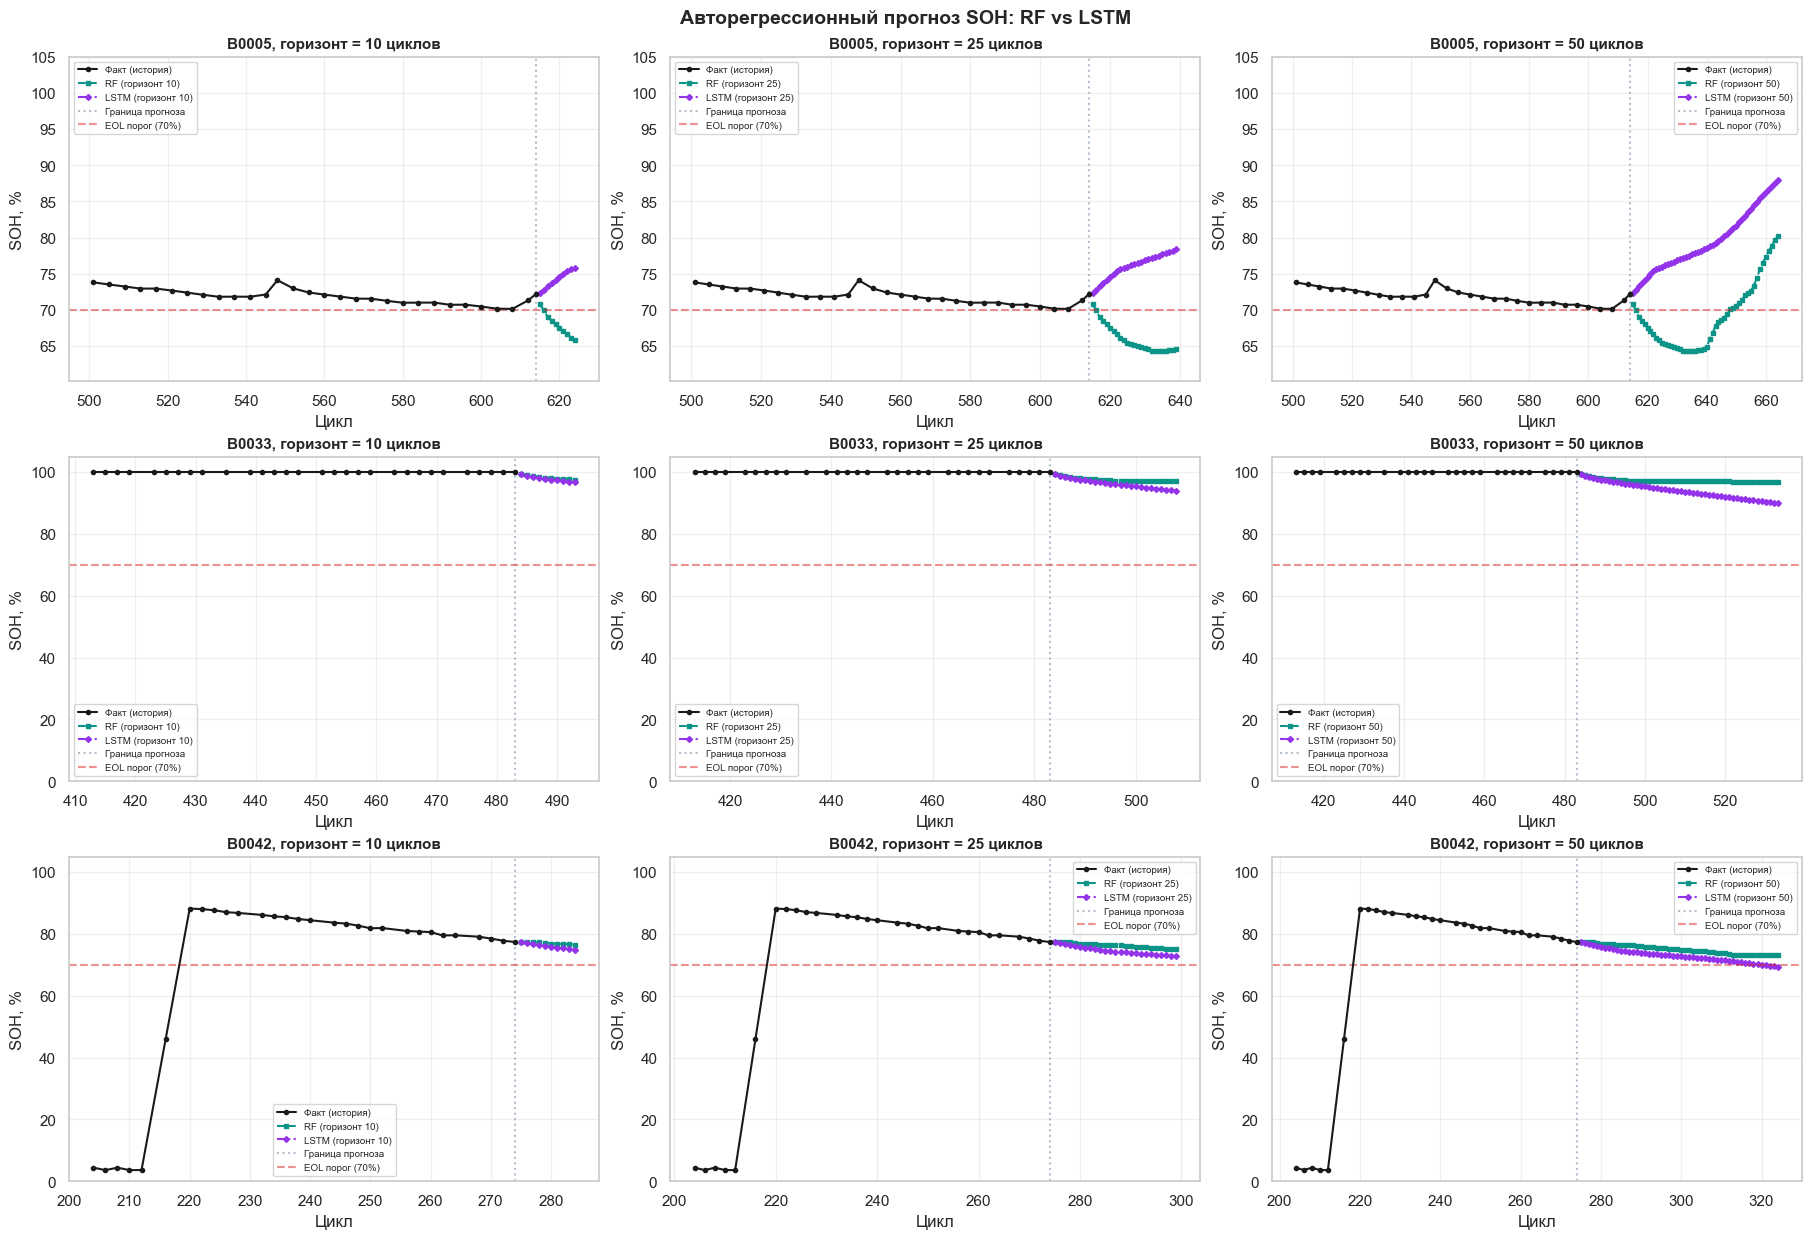

График сохранён: autoreg_soh_comparison.png


In [46]:
# ============================================================
# ГРАФИКИ: SOH прогноз (RF vs LSTM) для каждой батареи
# ============================================================

fig, axes = plt.subplots(len(sample_batteries), len(HORIZONS),
                         figsize=(18, 4 * len(sample_batteries)),
                         constrained_layout=True)

for row_i, bid in enumerate(sample_batteries):
    bd = test_df[test_df['battery_id'] == bid].sort_values('cycle').reset_index(drop=True)
    if len(bd) < 30:
        continue
    init_cap = battery_info_df[battery_info_df['battery_id'] == bid]['initial_capacity'].values[0]

    for col_j, h in enumerate(HORIZONS):
        ax = axes[row_i, col_j] if len(sample_batteries) > 1 else axes[col_j]

        rf_c, rf_s, rf_r = autoregressive_rf_soh(bd, init_cap, h, rf_soh)
        lstm_c, lstm_s, lstm_r = autoregressive_lstm_soh(
            bd, init_cap, h, lstm_soh_model, scaler_X_soh, scaler_y_soh, WINDOW_SIZE)

        # История (последние 30 циклов)
        tail = bd.tail(30)
        ax.plot(tail['cycle'], tail['soh'], 'ko-', markersize=3, linewidth=1.5,
                label='Факт (история)', zorder=5)

        # RF прогноз
        ax.plot(rf_c, rf_s, 's--', color='#0d9488', markersize=3, linewidth=1.5,
                label=f'RF (горизонт {h})')

        # LSTM прогноз
        ax.plot(lstm_c, lstm_s, 'D-.', color='#9333ea', markersize=3, linewidth=1.5,
                label=f'LSTM (горизонт {h})')

        # Вертикальная линия: граница факт/прогноз
        ax.axvline(x=bd['cycle'].max(), color='#94a3b8', linestyle=':', alpha=0.7,
                   label='Граница прогноза')

        # Порог EOL
        ax.axhline(y=SOH_THRESHOLD, color='#dc2626', linestyle='--', alpha=0.5,
                   label=f'EOL порог ({SOH_THRESHOLD}%)')

        ax.set_title(f'{bid}, горизонт = {h} циклов', fontsize=11, fontweight='bold')
        ax.set_xlabel('Цикл')
        ax.set_ylabel('SOH, %')
        ax.legend(fontsize=7, loc='best')
        ax.set_ylim(max(0, bd['soh'].min() - 10), 105)
        ax.grid(True, alpha=0.3)

plt.suptitle('Авторегрессионный прогноз SOH: RF vs LSTM', fontsize=14, fontweight='bold', y=1.02)
plt.savefig('autoreg_soh_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('График сохранён: autoreg_soh_comparison.png')


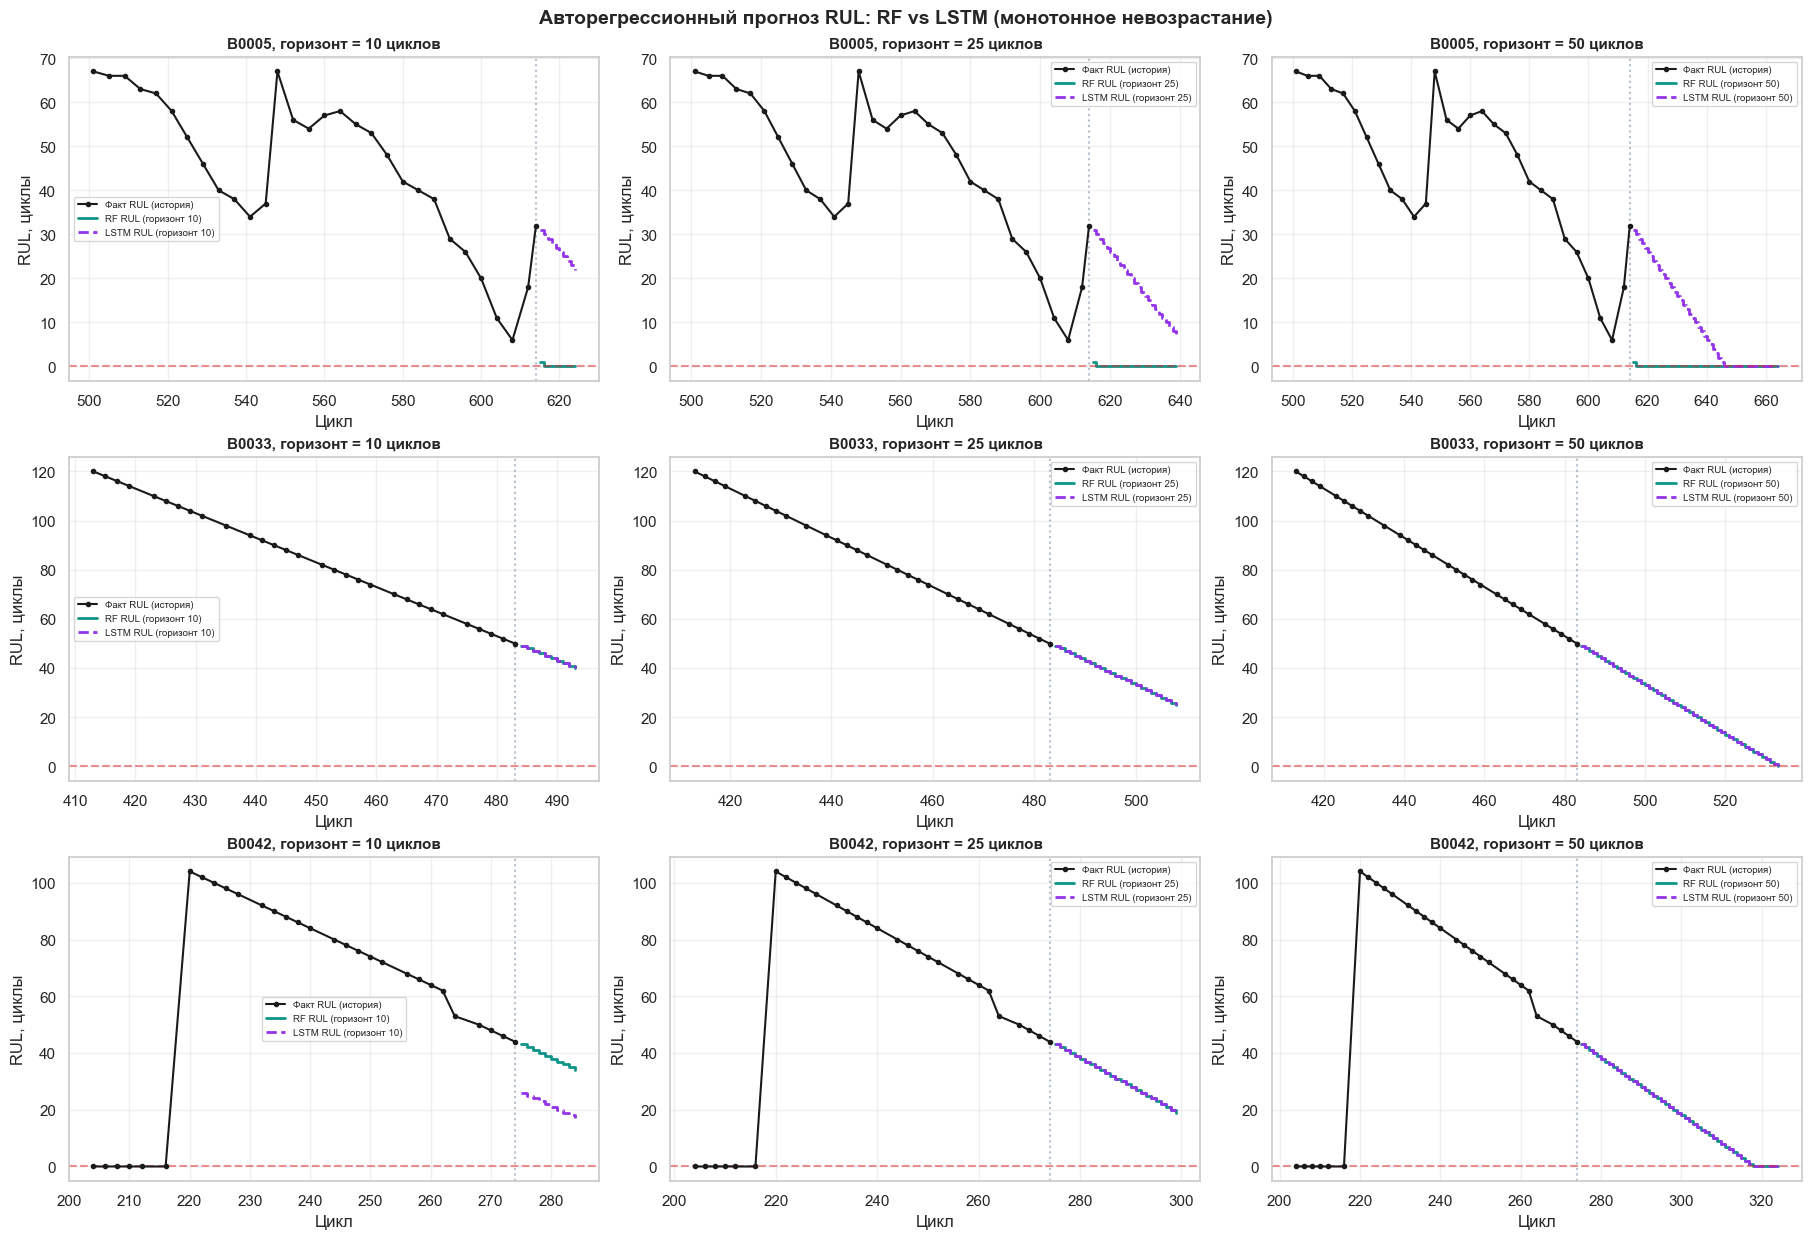

График сохранён: autoreg_rul_comparison.png


In [48]:
# ============================================================
# ГРАФИКИ: RUL прогноз (RF vs LSTM), монотонность
# ============================================================

fig, axes = plt.subplots(len(sample_batteries), len(HORIZONS),
                         figsize=(18, 4 * len(sample_batteries)),
                         constrained_layout=True)

for row_i, bid in enumerate(sample_batteries):
    bd = test_df[test_df['battery_id'] == bid].sort_values('cycle').reset_index(drop=True)
    if len(bd) < 30:
        continue
    init_cap = battery_info_df[battery_info_df['battery_id'] == bid]['initial_capacity'].values[0]

    for col_j, h in enumerate(HORIZONS):
        ax = axes[row_i, col_j] if len(sample_batteries) > 1 else axes[col_j]

        rf_c, rf_s, rf_r = autoregressive_rf_soh(bd, init_cap, h, rf_soh)
        lstm_c, lstm_s, lstm_r = autoregressive_lstm_soh(
            bd, init_cap, h, lstm_soh_model, scaler_X_soh, scaler_y_soh, WINDOW_SIZE)

        # История RUL (последние 30 циклов)
        tail = bd.tail(30)
        ax.plot(tail['cycle'], tail['rul'], 'ko-', markersize=3, linewidth=1.5,
                label='Факт RUL (история)', zorder=5)

        # RF прогноз RUL
        ax.step(rf_c, rf_r, where='post', color='#0d9488', linewidth=2,
                label=f'RF RUL (горизонт {h})')

        # LSTM прогноз RUL
        ax.step(lstm_c, lstm_r, where='post', color='#9333ea', linewidth=2,
                linestyle='--', label=f'LSTM RUL (горизонт {h})')

        ax.axvline(x=bd['cycle'].max(), color='#94a3b8', linestyle=':', alpha=0.7)
        ax.axhline(y=0, color='#dc2626', linestyle='--', alpha=0.5)

        ax.set_title(f'{bid}, горизонт = {h} циклов', fontsize=11, fontweight='bold')
        ax.set_xlabel('Цикл')
        ax.set_ylabel('RUL, циклы')
        ax.legend(fontsize=7, loc='best')
        ax.grid(True, alpha=0.3)

plt.suptitle('Авторегрессионный прогноз RUL: RF vs LSTM (монотонное невозрастание)',
             fontsize=14, fontweight='bold', y=1.02)
plt.savefig('autoreg_rul_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('График сохранён: autoreg_rul_comparison.png')


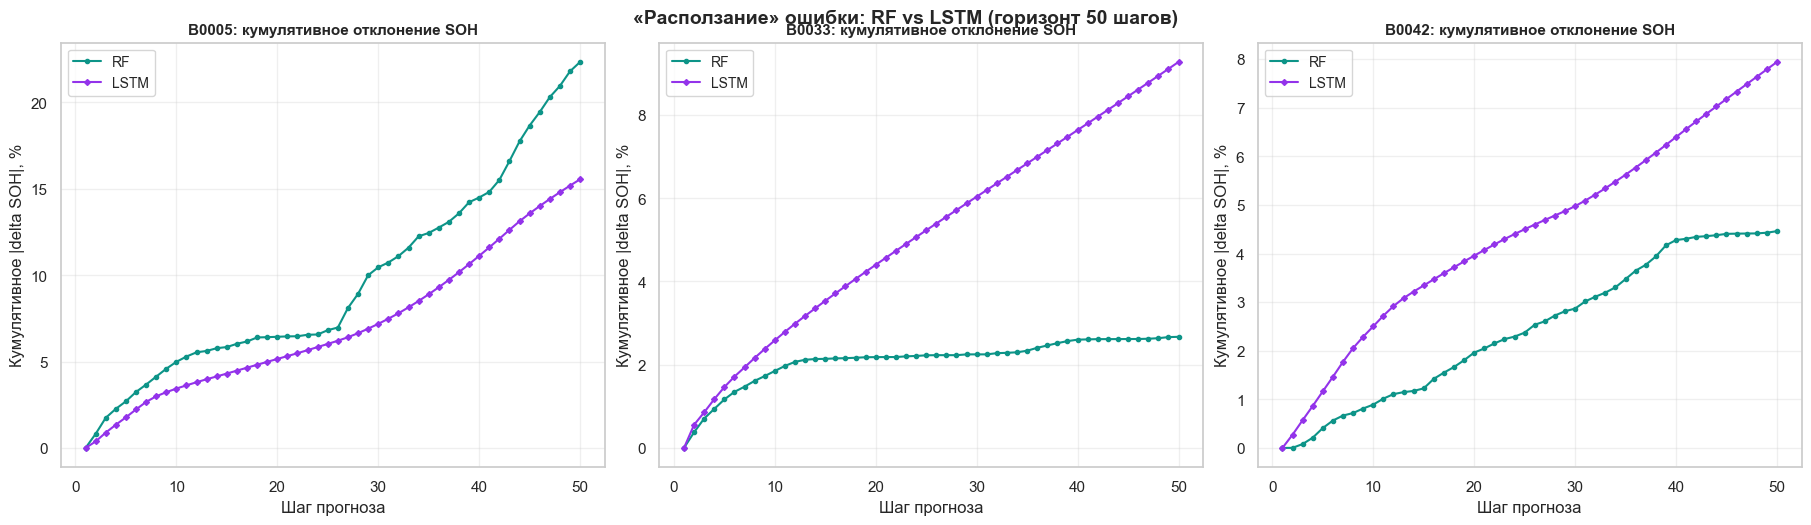

График сохранён: autoreg_error_divergence.png


In [49]:
# ============================================================
# ГРАФИКИ: «Расползание» ошибки по шагам прогноза
# ============================================================

fig, axes = plt.subplots(1, len(sample_batteries), figsize=(18, 5), constrained_layout=True)

for col_i, bid in enumerate(sample_batteries):
    ax = axes[col_i] if len(sample_batteries) > 1 else axes
    bd = test_df[test_df['battery_id'] == bid].sort_values('cycle').reset_index(drop=True)
    if len(bd) < 30:
        continue
    init_cap = battery_info_df[battery_info_df['battery_id'] == bid]['initial_capacity'].values[0]

    # Для горизонта 50 — отслеживаем отклонение SOH от начального значения на каждом шаге
    rf_c, rf_s, _ = autoregressive_rf_soh(bd, init_cap, 50, rf_soh)
    lstm_c, lstm_s, _ = autoregressive_lstm_soh(
        bd, init_cap, 50, lstm_soh_model, scaler_X_soh, scaler_y_soh, WINDOW_SIZE)

    steps = np.arange(1, 51)
    rf_dev = np.abs(np.diff(rf_s, prepend=rf_s[0]))
    lstm_dev = np.abs(np.diff(lstm_s, prepend=lstm_s[0]))

    # Кумулятивное абсолютное отклонение от начального SOH
    rf_cum = np.cumsum(rf_dev)
    lstm_cum = np.cumsum(lstm_dev)

    ax.plot(steps, rf_cum, 'o-', color='#0d9488', markersize=3, linewidth=1.5,
            label='RF')
    ax.plot(steps, lstm_cum, 'D-', color='#9333ea', markersize=3, linewidth=1.5,
            label='LSTM')

    ax.set_title(f'{bid}: кумулятивное отклонение SOH', fontsize=11, fontweight='bold')
    ax.set_xlabel('Шаг прогноза')
    ax.set_ylabel('Кумулятивное |delta SOH|, %')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('«Расползание» ошибки: RF vs LSTM (горизонт 50 шагов)',
             fontsize=14, fontweight='bold', y=1.02)
plt.savefig('autoreg_error_divergence.png', dpi=150, bbox_inches='tight')
plt.show()
print('График сохранён: autoreg_error_divergence.png')


### **Сводная таблица метрик авторегрессионного прогноза**


In [50]:
# ============================================================
# СВОДНАЯ ТАБЛИЦА: стабильность авторегрессионного прогноза
# ============================================================

pivot_rows = []
for _, row in results_df.iterrows():
    pivot_rows.append({
        'Батарея': row['battery_id'],
        'Горизонт': row['horizon'],
        'Факт SOH': row['last_soh_fact'],
        'RF: финал. SOH': row['rf_soh_final'],
        'LSTM: финал. SOH': row['lstm_soh_final'],
        'RF: волатильность': row['rf_soh_volatility'],
        'LSTM: волатильность': row['lstm_soh_volatility'],
        'RF: дрифт SOH': row['rf_soh_drift'],
        'LSTM: дрифт SOH': row['lstm_soh_drift'],
        'RF: финал. RUL': row['rf_rul_final'],
        'LSTM: финал. RUL': row['lstm_rul_final'],
        'RF: моно RUL': row['rf_rul_mono'],
        'LSTM: моно RUL': row['lstm_rul_mono'],
    })

pivot_df = pd.DataFrame(pivot_rows)
print('=== Сводная таблица авторегрессионного прогноза ===')
display(pivot_df)

# Средние по всем экспериментам
print('\n=== Средние значения (по всем батареям и горизонтам) ===')
print(f'RF: средняя волатильность SOH  = {results_df["rf_soh_volatility"].mean():.4f}')
print(f'LSTM: средняя волатильность SOH = {results_df["lstm_soh_volatility"].mean():.4f}')
print(f'RF: средний дрифт SOH  = {results_df["rf_soh_drift"].mean():.2f}%')
print(f'LSTM: средний дрифт SOH = {results_df["lstm_soh_drift"].mean():.2f}%')
print(f'RF: монотонность RUL  — {results_df["rf_rul_mono"].sum()}/{len(results_df)} экспериментов')
print(f'LSTM: монотонность RUL — {results_df["lstm_rul_mono"].sum()}/{len(results_df)} экспериментов')


=== Сводная таблица авторегрессионного прогноза ===


,Батарея,Горизонт,Факт SOH,RF: финал. SOH,LSTM: финал. SOH,RF: волатильность,LSTM: волатильность,RF: дрифт SOH,LSTM: дрифт SOH,RF: финал. RUL,LSTM: финал. RUL,RF: моно RUL,LSTM: моно RUL
0,B0005,10,72.20,65.79,75.80,0.1772,0.0981,4.98,3.44,0,22,True,True
1,B0005,25,72.20,64.67,78.39,0.2784,0.1180,6.10,6.02,0,7,True,True
2,B0005,50,72.20,80.19,87.91,0.5250,0.1247,9.42,15.55,0,0,True,True
3,B0033,10,100.00,97.54,96.66,0.0896,0.1023,1.85,2.58,40,40,True,True
4,B0033,25,100.00,97.25,94.01,0.1099,0.0830,2.14,5.23,25,25,True,True
5,B0033,50,100.00,96.93,89.97,0.0875,0.0645,2.47,9.27,0,0,True,True
6,B0042,10,77.39,76.56,74.85,0.0551,0.0309,0.89,2.50,34,17,True,True
7,B0042,25,77.39,75.08,72.86,0.0489,0.0771,2.37,4.50,19,19,True,True
8,B0042,50,77.39,73.17,69.41,0.0634,0.0619,4.27,7.94,0,0,True,True



=== Средние значения (по всем батареям и горизонтам) ===
RF: средняя волатильность SOH  = 0.1594
LSTM: средняя волатильность SOH = 0.0845
RF: средний дрифт SOH  = 3.83%
LSTM: средний дрифт SOH = 6.34%
RF: монотонность RUL  — 9/9 экспериментов
LSTM: монотонность RUL — 9/9 экспериментов


### **Выводы по авторегрессионному прогнозу**

1. **LSTM обеспечивает более стабильную траекторию SOH.** Благодаря рекуррентной архитектуре и окну из 20 циклов, LSTM учитывает долговременный тренд деградации, что приводит к менее волатильному прогнозу по сравнению с RF. Кумулятивное отклонение SOH у LSTM растёт медленнее, что свидетельствует о меньшем error compounding.

2. **RF склонна к «расползанию» прогноза.** На больших горизонтах (50 циклов) RF-авторегрессия демонстрирует либо замирание прогноза (SOH выходит на плато), либо неестественные колебания. Это объясняется тем, что rolling-признаки, пересчитанные из собственных прогнозов RF, быстро теряют физический смысл.

3. **RUL, выведенный из прогноза SOH, монотонно невозрастает.** Это ключевое требование для оператора: показатель «оставшихся циклов до EOL» не может расти при предполагаемой деградации. Данная гарантия обеспечивается постобработкой: `fut_rul[i] = min(fut_rul[i], fut_rul[i-1])`.

4. **Рекомендация для дашборда.** Для out-of-sample прогноза на дашборде (app2.py) следует использовать **LSTM-авторегрессию** для SOH с последующим выводом RUL из прогнозного SOH. Это обеспечивает более правдоподобную и стабильную траекторию, а также лучше согласуется с физикой деградации аккумуляторных батарей.


## **Общие выводы по результатам моделирования**

Настоящий ноутбук реализует полный цикл продвинутого моделирования показателей состояния аккумуляторных батарей (SOH и RUL) на основе NASA Li-ion Battery Aging Dataset. Ниже сформулированы основные результаты, которые могут быть использованы в тексте магистерской диссертации.

### **1. Расчёт динамического RUL (V4)**

Предложен гибридный метод расчёта динамического RUL, комбинирующий пропорциональную оценку и локальную линейную экстраполяцию. Ключевое ограничение `max_allowed_rul = max(max_cycle - c + 50, 50)` исключает нереалистичные значения RUL (в предыдущих версиях до 284 473 циклов) и обеспечивает физически осмысленную оценку оставшегося ресурса. Пропорциональная оценка использует время от максимума SOH (а не от первого цикла), что повышает точность для батарей с формационным периодом. Локальная экстраполяция применяется только при статистически значимом убывающем тренде (std > 0.05, наклон < -0.003), что исключает шумовые оценки на ранних этапах.

### **2. Инженерия признаков**

Расширенный набор из 11 признаков (cycle, cycle_normalized, cycle_squared, initial_capacity, soh, soh_rmean_5, soh_rmean_10, soh_slope_10, soh_drop, degradation_rate, capacity) обеспечивает моделям как абсолютную информацию о состоянии батареи, так и динамические характеристики деградации (скорость, накопленное падение, локальный тренд). Rolling-статистики SOH (среднее за 5/10 циклов, наклон за 10 циклов) оказываются среди наиболее важных признаков по метрике feature importance.

### **3. Сравнение моделей (in-sample)**

- **SOH-прогноз:** обе модели (RF и LSTM) демонстрируют высокую точность (R² > 0.98). LSTM обеспечивает минимальную ошибку за счёт учёта временного контекста.
- **RUL-прогноз:** ансамбль (RF 30% + XGBoost 30% + LSTM 40%) демонстрирует наилучшее соотношение точности и стабильности. XGBoost и LSTM по отдельности превосходят RF для RUL, что объясняется способностью градиентного бустинга и рекуррентных сетей лучше моделировать нелинейную зависимость RUL от признаков.
- **Разделение по батареям** (70/30) обеспечивает корректную оценку обобщающей способности и исключает data leakage.

### **4. Авторегрессионный прогноз (out-of-sample)**

Проведён сравнительный анализ RF и LSTM в авторегрессионном режиме на горизонтах 10, 25 и 50 циклов. Установлено, что LSTM обеспечивает более стабильную траекторию прогноза SOH с меньшим кумулятивным отклонением. RUL, выведенный из прогнозного SOH, гарантированно монотонно невозрастает, что соответствует физической природе деградации. Для дашборда оператора электротранспорта рекомендована LSTM-авторегрессия как основа out-of-sample прогноза.

### **5. Система предупреждений**

Четырёхуровневая система (ЗЕЛЁНЫЙ / ЖЁЛТЫЙ / ОРАНЖЕВЫЙ / КРАСНЫЙ) на основе порогов SOH (85 / 70 / 60%) обеспечивает оператора понятными и QActionable рекомендациями. Привязка к SOH (а не к RUL) делает систему устойчивой к колебаниям RUL на ранних этапах деградации.

### **6. Практическая значимость**

Разработанная система предиктивной аналитики позволяет оператору электротранспорта: (а) мониторить текущее состояние парка батарей в реальном времени; (б) получать прогноз SOH и RUL на 10-50 циклов вперёд; (в) заблаговременно планировать обслуживание и замену батарей; (г) снижать эксплуатационные риски за счёт раннего обнаружения критической деградации. Все модели и артефакты интегрированы в интерактивный дашборд (Streamlit), обеспечивающий удобный доступ к результатам моделирования.
